# Regression Refresher: Predicting BTC 24h Realized Volatility

End-to-end regression workflow on a real crypto dataset. Each major section ends
with **exercises** (problem -> empty scaffold -> hidden solution) so you can
practise implementing every step yourself.

**Target**: 24h forward realized volatility of BTC, defined as

$$
RV_t \;=\; \sqrt{\sum_{h=1}^{24} r_{t+h}^{2}} \cdot \sqrt{24}
$$

where $r_{t+h} = \ln(C_{t+h}/C_{t+h-1})$ is the hourly log return.
We treat this as a tabular regression problem and benchmark classical ML against
strong vol baselines (persistence, HAR-RV).


## 0. Setup & imports

CPU-only stack: numpy / pandas / sklearn / xgboost / lightgbm / optuna / shap.
Set seeds so the notebook is reproducible.

In [1]:
import warnings, os, json, time, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import joblib

from scipy import stats

SEED = 42
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 4)

DATA_PATH = '/home/zlac116/Code/learning/ml-revision/data/crypto_hourly.parquet'
ARTIFACT_DIR = '/home/zlac116/Code/learning/ml-revision/regression/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print('imports ok')

imports ok


## 1. Problem framing

We are predicting **a positive, fat-tailed, highly auto-correlated quantity**
(realized vol). That has consequences for the entire pipeline:

- **Loss**: MAE/RMSE are fine for a refresher, but in vol-forecasting literature
  the **QLIKE** loss is preferred because it penalises under-prediction more
  heavily and is robust to outliers:
  $$ \mathrm{QLIKE}(\hat\sigma^2, \sigma^2) = \frac{\sigma^2}{\hat\sigma^2} - \ln\frac{\sigma^2}{\hat\sigma^2} - 1 $$
- **Persistence baseline is strong**: vol clusters, so "tomorrow's vol = today's
  vol" is a brutal benchmark. If you crush it by 50%, you are leaking.
- **Time-aware splitting only**: no shuffled CV, no group-K-fold. Rolling /
  expanding windows.
- **Stationarity**: vol regimes change, so we will check OOS robustness, not
  just an aggregate test number.

## 2. Data loading & sanity

Load the shared parquet, check schema, look for gaps. Crypto data is *usually*
clean on majors but small drops happen (exchange downtime, ingestion gaps).
Catching these early prevents NaNs from poisoning rolling features later.

In [2]:
raw = pd.read_parquet(DATA_PATH)
raw['ts'] = pd.to_datetime(raw['ts'], utc=True)
raw = raw.sort_values(['symbol', 'ts']).reset_index(drop=True)
print('shape:', raw.shape)
print('symbols:', sorted(raw['symbol'].unique()))
print('range :', raw['ts'].min(), '->', raw['ts'].max())
raw.head()

shape: (70080, 7)
symbols: ['BNB', 'BTC', 'ETH', 'SOL']
range : 2024-04-19 23:00:00+00:00 -> 2026-04-19 22:00:00+00:00


,ts,open,high,low,close,volume,symbol
0,2024-04-19 23:00:00+00:00,556.7,557.0,549.6,554.0,21953.020,BNB
1,2024-04-20 00:00:00+00:00,554.1,557.1,551.2,551.4,14108.411,BNB
2,2024-04-20 01:00:00+00:00,551.3,557.4,548.8,556.9,12407.915,BNB
3,2024-04-20 02:00:00+00:00,556.9,558.1,554.7,557.0,7299.961,BNB
4,2024-04-20 03:00:00+00:00,557.1,558.1,555.6,556.5,5680.975,BNB


In [3]:
# basic sanity: per-symbol coverage and duplicates
sanity = (raw.groupby('symbol')
              .agg(rows=('ts', 'size'),
                   first=('ts', 'min'),
                   last=('ts', 'max'),
                   dupes=('ts', lambda s: int(s.duplicated().sum())))
              .reset_index())
sanity['days'] = (sanity['last'] - sanity['first']).dt.total_seconds() / 86400
sanity

,symbol,rows,first,last,dupes,days
0,BNB,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333
1,BTC,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333
2,ETH,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333
3,SOL,17520,2024-04-19 23:00:00+00:00,2026-04-19 22:00:00+00:00,0,729.958333


### Exercises (Section 2)

**Before you start — techniques you'll use:**

- **Per-group missing-rate**: `df.set_index('ts').groupby('symbol').apply(lambda g:
  g.isna().mean() * 100)` — one row per symbol, one column per field.
- **Gap finding**: sort `ts`, `diff()`, `idxmax()` for the position of the largest
  timedelta; pair with `.loc[[i-1, i]]` to show the bracketing timestamps.
- **Expected hourly grid**: `pd.date_range(min, max, freq='1h', tz='UTC')`, then
  `full.difference(btc.index)` surfaces the exact missing timestamps.
- **Floor to day for count plots**: `ts.dt.floor('D')` then
  `.groupby(...).size()` — one integer per day.

*Mini-example (longest gap location):*
```python
diffs = btc['ts'].sort_values().reset_index(drop=True).diff()
i = int(diffs.idxmax())
print('longest gap:', diffs.iloc[i], '@', btc['ts'].iloc[i])
```


**Worked example — per-symbol hygiene on a tiny multi-asset frame**

Shows the four idioms you'll use: per-symbol missing %, the longest gap location,
expected hourly grid via `pd.date_range`, and rows-per-day via `dt.floor('D')`.


In [4]:
import numpy as np, pandas as pd

ts = pd.to_datetime([
    '2024-01-01 00:00', '2024-01-01 01:00', '2024-01-01 04:00',  # 3h gap on A
    '2024-01-01 00:00', '2024-01-01 01:00', '2024-01-01 02:00',
], utc=True)
toy = pd.DataFrame({'ts': ts, 'symbol': ['A','A','A','B','B','B'],
                    'close': [100, np.nan, 103, 50, 51, 52]})

# 1) Per-symbol % missing.
miss = (toy.set_index('ts').groupby('symbol').apply(lambda g: g.isna().mean() * 100))
print('% missing per symbol:'); print(miss, '\n')

# 2) Longest gap location for symbol A.
a_ts = toy[toy.symbol == 'A']['ts'].sort_values().reset_index(drop=True)
diffs = a_ts.diff()
i = int(diffs.idxmax())
print(f'A longest gap: {diffs.iloc[i]} between {a_ts.iloc[i-1]} and {a_ts.iloc[i]}')

# 3) Expected hourly grid vs actual — surfaces missing timestamps.
expected = pd.date_range(a_ts.min(), a_ts.max(), freq='1h', tz='UTC')
print(f'\nA missing timestamps: {expected.difference(a_ts).tolist()}')

# 4) Rows per calendar day.
per_day = toy.groupby(toy['ts'].dt.floor('D')).size()
print('\nrows per day:'); print(per_day)


% missing per symbol:
        symbol      close
symbol                   
A          0.0  33.333333
B          0.0   0.000000 

A longest gap: 0 days 03:00:00 between 2024-01-01 01:00:00+00:00 and 2024-01-01 04:00:00+00:00

A missing timestamps: [Timestamp('2024-01-01 02:00:00+0000', tz='UTC'), Timestamp('2024-01-01 03:00:00+0000', tz='UTC')]

rows per day:
ts
2024-01-01 00:00:00+00:00    6
dtype: int64


**Exercise 2.1** - Compute the percentage of missing values for each
column, broken down per symbol. Return a tidy DataFrame with one row per
(symbol, column). Expected: very small or zero values for this dataset.

In [5]:
# Your answer here


**Expected output:**

> ⚠️ _The reference solution in the `<details>` block currently errors (`ValueError: cannot insert symbol, already exists`). Treat the details block's commentary as the reference, not any output shown here._

<details>
<summary>💡 Click to reveal solution</summary>

```python
miss = (raw.set_index('ts')
            .groupby('symbol')
            .apply(lambda g: g.isna().mean() * 100)
            .reset_index()
            .melt(id_vars='symbol', var_name='column', value_name='pct_missing'))
miss.sort_values('pct_missing', ascending=False).head(10)
```

**Explanation**: `groupby(symbol).apply(isna().mean())` gives proportions per column; multiply by 100 and melt to long form. For this clean dataset all values are 0%.

</details>

**Exercise 2.2** - Find the **longest gap** in BTC's series. Return the
gap duration (Timedelta), start ts, and end ts. Hint: `diff()` on a sorted
timestamp index.

In [6]:
# Your answer here


**Expected output:**

```text
longest gap: 0 days 01:00:00  between 2024-04-19 23:00:00+00:00 and 2024-04-20 00:00:00+00:00
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
btc_ts = raw[raw.symbol == 'BTC']['ts'].sort_values().reset_index(drop=True)
gaps = btc_ts.diff()
i = int(gaps.idxmax())
print('longest gap:', gaps.iloc[i],
      ' between', btc_ts.iloc[i-1], 'and', btc_ts.iloc[i])
```

**Explanation**: Sort, diff, take the argmax. For a clean hourly dataset this should be 1 hour exactly.

</details>

**Exercise 2.3** - Verify hourly continuity for BTC by reindexing on the
full hourly range and counting how many hours are missing. Expected: 0 or close
to 0.

In [7]:
# Your answer here


**Expected output:**

```text
expected hours: 17520  actual: 17520  missing: 0
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
btc = raw[raw.symbol == 'BTC'].set_index('ts').sort_index()
full = pd.date_range(btc.index.min(), btc.index.max(), freq='1h', tz='UTC')
missing = full.difference(btc.index)
print('expected hours:', len(full),
      ' actual:', len(btc),
      ' missing:', len(missing))
```

**Explanation**: `pd.date_range` builds the canonical hourly grid; `difference` against the actual index pinpoints missing hours -- the standard reindex-and-check pattern.

</details>

**Exercise 2.4** - Plot the number of rows per calendar day for BTC. Days
with fewer than 24 rows indicate dropped hours. Use a line plot with day on x
and row count on y.

In [8]:
# Your answer here


**Expected output:**

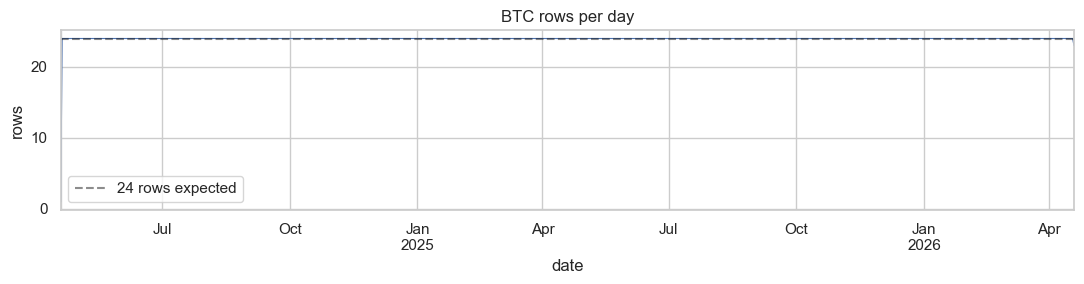

<details>
<summary>💡 Click to reveal solution</summary>

```python
btc = raw[raw.symbol == 'BTC'].copy()
per_day = btc.groupby(btc['ts'].dt.floor('D')).size()
fig, ax = plt.subplots(figsize=(11, 3))
per_day.plot(ax=ax, lw=0.8)
ax.axhline(24, color='k', ls='--', alpha=0.5, label='24 rows expected')
ax.set_title('BTC rows per day'); ax.set_xlabel('date'); ax.set_ylabel('rows')
ax.legend(); plt.tight_layout()
```

**Explanation**: Floor timestamps to day, group, count. Dips below 24 are exchange or ingestion outages.

</details>

## 3. Exploratory data analysis

Three things we MUST verify visually for any vol-forecasting problem:

1. **Fat-tailed return distribution** -> motivates robust losses, log targets.
2. **Vol clustering**: ACF of squared returns decays slowly -> persistence
   baseline will be strong.
3. **Seasonality**: weekly / hourly patterns in vol can drive feature design.


In [9]:
# build a wide BTC frame for EDA
btc = (raw[raw.symbol == 'BTC']
       .set_index('ts').sort_index()[['open','high','low','close','volume']]
       .copy())
btc['log_ret'] = np.log(btc['close'] / btc['close'].shift(1))
btc.head()

,open,high,low,close,volume,log_ret
ts,,,,,,
2024-04-19 23:00:00+00:00,64012.49,64124.00,62953.90,63818.01,2825.31770,NaN
2024-04-20 00:00:00+00:00,63818.01,64263.41,63418.00,63444.51,2107.44280,-0.005870
2024-04-20 01:00:00+00:00,63444.51,63777.03,63090.07,63656.00,1283.85296,0.003328
2024-04-20 02:00:00+00:00,63656.00,64092.29,63530.00,63834.02,882.54344,0.002793
2024-04-20 03:00:00+00:00,63834.01,64040.67,63766.00,63956.00,634.11376,0.001909


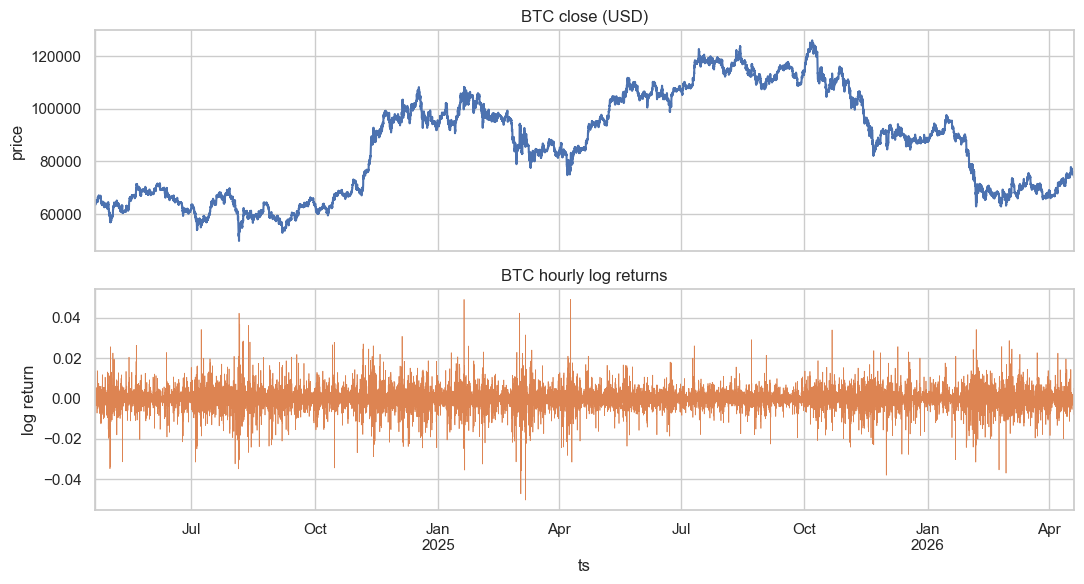

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
btc['close'].plot(ax=axes[0], color='C0')
axes[0].set_title('BTC close (USD)'); axes[0].set_ylabel('price')
btc['log_ret'].plot(ax=axes[1], color='C1', lw=0.5)
axes[1].set_title('BTC hourly log returns'); axes[1].set_ylabel('log return')
plt.tight_layout()

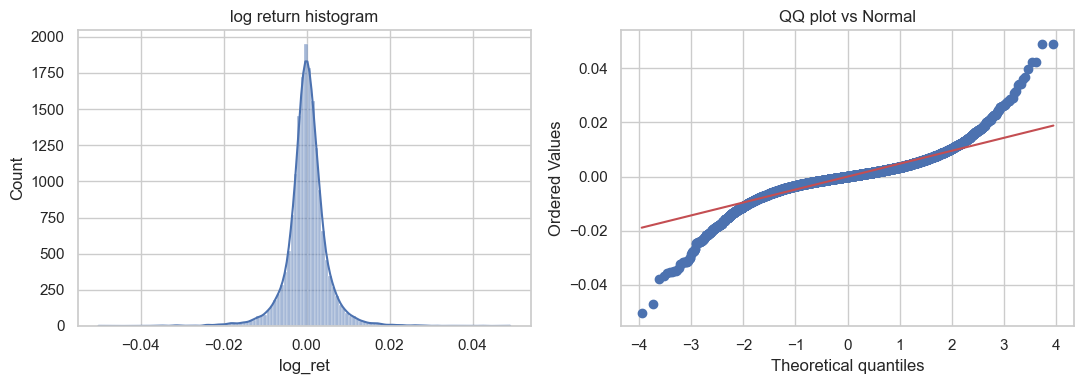

In [11]:
# return distribution: clear fat tails
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(btc['log_ret'].dropna(), bins=120, kde=True, ax=axes[0])
axes[0].set_title('log return histogram')
stats.probplot(btc['log_ret'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ plot vs Normal')
plt.tight_layout()

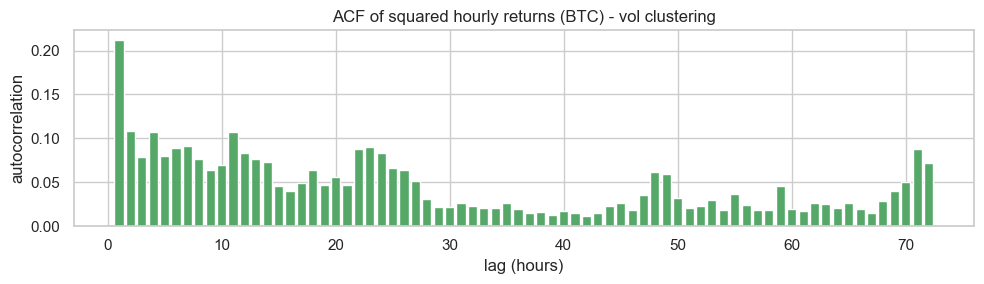

In [12]:
# ACF of squared returns -> volatility clustering
from pandas.plotting import autocorrelation_plot
sq = (btc['log_ret']**2).dropna()
lags = np.arange(1, 73)
acf_vals = [sq.autocorr(lag=l) for l in lags]
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(lags, acf_vals, color='C2')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('ACF of squared hourly returns (BTC) - vol clustering')
ax.set_xlabel('lag (hours)'); ax.set_ylabel('autocorrelation')
plt.tight_layout()

### Exercises (Section 3)

**Before you start — techniques you'll use:**

- **Realized volatility**: `np.sqrt((log_ret ** 2).rolling(w).sum()) * np.sqrt(w)`
  annualises per-hour vol to match the sampling window.
- **Skew / excess kurt**: `scipy.stats.skew(r)`, `scipy.stats.kurtosis(r)` (Fisher
  convention — 0 means Normal).
- **Weekday seasonality**: `rv.index.day_name()` gives strings; pass an explicit
  `order=['Monday', ..., 'Sunday']` to `sns.boxplot` so the axis stays intuitive.
- **Lag scatter**: build `pd.DataFrame({'rv': rv, 'rv_lag24': rv.shift(24)}).dropna()`;
  persistence shows up as a positive slope.

*Mini-example (rolling RV):*
```python
rv_24h = np.sqrt((btc['log_ret'] ** 2).rolling(24).sum()) * np.sqrt(24)
```


**Worked example — returns, vol, and seasonality**

Demonstrates rolling realised vol, skew/kurtosis, weekday seasonality boxplot, and a
lag-scatter that exposes vol-of-vol persistence. Same idioms as the four exercises.


rolling 24h RV — mean: 0.2369
skew: +0.002    excess kurt: -0.055


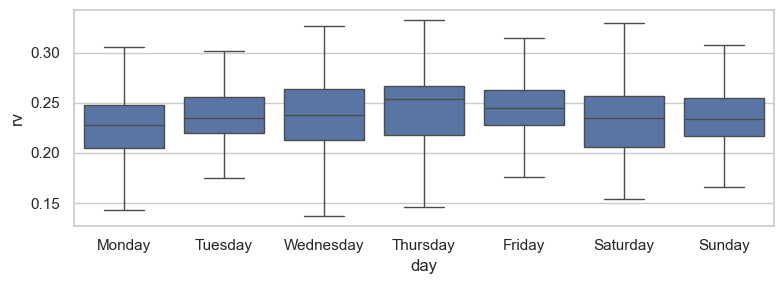


corr(rv(t), rv(t-24)) = +0.052  (positive → persistence)


In [13]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*120, freq='1h', tz='UTC')
log_ret = pd.Series(rng.normal(0, 0.01, len(idx)), index=idx)

# 1) Rolling 24h realised vol.
rv = np.sqrt((log_ret ** 2).rolling(24).sum()) * np.sqrt(24)
print(f'rolling 24h RV — mean: {rv.mean():.4f}')

# 2) Skew / excess kurt of the return distribution.
print(f'skew: {stats.skew(log_ret):+.3f}    excess kurt: {stats.kurtosis(log_ret):+.3f}')

# 3) Weekday boxplot of realised vol.
df = pd.DataFrame({'rv': rv, 'day': rv.index.day_name()}).dropna()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(data=df, x='day', y='rv', order=order, showfliers=False, ax=ax)
plt.tight_layout(); plt.show()

# 4) Lag scatter: rv(t) vs rv(t-24).
lag = pd.DataFrame({'rv': rv, 'rv_lag24': rv.shift(24)}).dropna()
print(f'\ncorr(rv(t), rv(t-24)) = {lag.corr().iloc[0,1]:+.3f}  (positive → persistence)')


**Exercise 3.1** - Plot the rolling 24h realized volatility of BTC over
time (the same quantity we will predict). Use the formula
`sqrt(rolling_24h(log_ret^2)) * sqrt(24)`. Title and axis labels mandatory.

In [14]:
# Your answer here


**Expected output:**

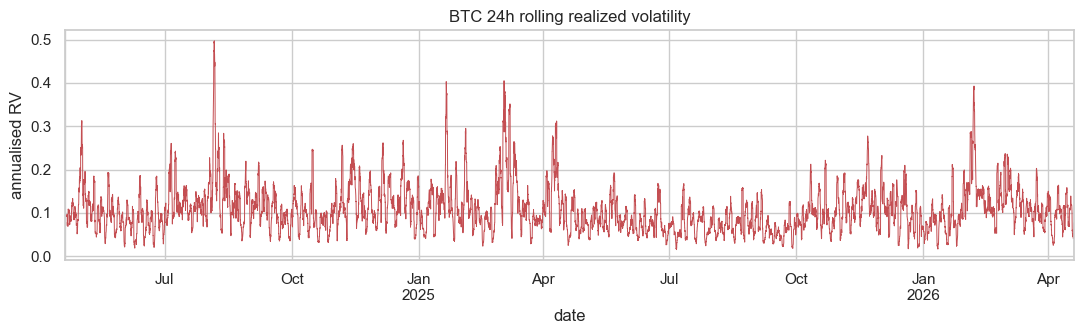

<details>
<summary>💡 Click to reveal solution</summary>

```python
rv = np.sqrt((btc['log_ret']**2).rolling(24).sum()) * np.sqrt(24)
fig, ax = plt.subplots(figsize=(11, 3.5))
rv.plot(ax=ax, color='C3', lw=0.7)
ax.set_title('BTC 24h rolling realized volatility')
ax.set_xlabel('date'); ax.set_ylabel('annualised RV')
plt.tight_layout()
```

**Explanation**: Sum squared returns over a 24h window, sqrt and scale by sqrt(24) to annualise from hourly. This is the *backward-looking* twin of our target.

</details>

**Exercise 3.2** - Compute the skew and excess kurtosis of BTC hourly log
returns. A normal distribution has skew=0 and excess kurt=0. What do you
observe?

In [15]:
# Your answer here


**Expected output:**

```text
skew         : -0.170
excess kurt  : +9.418
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
r = btc['log_ret'].dropna()
print(f'skew         : {stats.skew(r):+.3f}')
print(f'excess kurt  : {stats.kurtosis(r):+.3f}')
```

**Explanation**: Crypto returns typically show modest skew and *very* high kurtosis (fat tails). This is why squared returns are so informative for vol forecasting and why we may want a log-transformed target.

</details>

**Exercise 3.3** - Boxplot of realized 24h vol by **weekday**. Is there a
visually obvious weekday effect? (Use `dt.day_name()`.)

In [16]:
# Your answer here


**Expected output:**

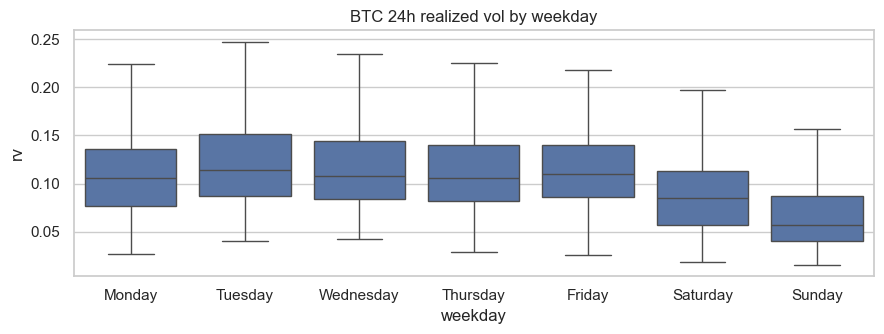

<details>
<summary>💡 Click to reveal solution</summary>

```python
rv = np.sqrt((btc['log_ret']**2).rolling(24).sum()) * np.sqrt(24)
df_w = pd.DataFrame({'rv': rv, 'weekday': rv.index.day_name()}).dropna()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.boxplot(data=df_w, x='weekday', y='rv', order=order, showfliers=False, ax=ax)
ax.set_title('BTC 24h realized vol by weekday')
plt.tight_layout()
```

**Explanation**: Weekend liquidity tends to be lower in crypto so we sometimes see slightly elevated vol; the effect is usually weak but visible. Day-of-week is therefore a worthwhile feature.

</details>

**Exercise 3.4** - Scatter realized vol at time t vs realized vol at time
t-24 (one-day-lagged). This visualises the autocorrelation that makes
persistence so hard to beat. Add a y=x line for reference.

In [17]:
# Your answer here


**Expected output:**

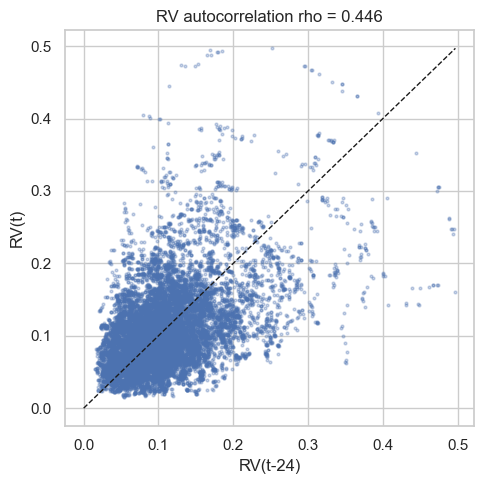

<details>
<summary>💡 Click to reveal solution</summary>

```python
rv = np.sqrt((btc['log_ret']**2).rolling(24).sum()) * np.sqrt(24)
df = pd.DataFrame({'rv': rv, 'rv_lag24': rv.shift(24)}).dropna()
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(df['rv_lag24'], df['rv'], s=4, alpha=0.3)
lim = [0, df.max().max()]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('RV(t-24)'); ax.set_ylabel('RV(t)')
ax.set_title(f"RV autocorrelation rho = {df.corr().iloc[0,1]:.3f}")
plt.tight_layout()
```

**Explanation**: Strong positive correlation around the y=x line is the visual signature of vol persistence. Any model must beat this trivial relationship.

</details>

## 4. Feature engineering (leakage-free)

Every feature is **strictly backward-looking** with respect to time `t`. The
target uses returns over `(t, t+24]`. To stay safe:

- All rolling windows end *at or before* `t` (use `.shift(1)` AFTER the rolling
  if the rolling closes on the last bar by default in pandas).
- Cross-asset features at time `t` use only data up to `t` for the OTHER asset.
- Drop NaNs from rolling **and** target windows together.

**HAR-RV** (Corsi 2009) is a very strong vol baseline: model RV as a linear
combination of yesterday's RV, last week's average RV, and last month's average
RV. We will include those three features explicitly.

**Range estimators** use the high/low/open/close to form variance estimates that
are statistically more efficient than squared close-to-close returns:

- **Parkinson**: $\sigma^2 = \frac{1}{4 \ln 2} (\ln H/L)^2$
- **Garman-Klass**: $\sigma^2 = 0.5 (\ln H/L)^2 - (2\ln 2 - 1)(\ln C/O)^2$


In [18]:
# build per-symbol feature frames, target is 24h FORWARD RV of BTC
def hourly_log_ret(df):
    return np.log(df['close'] / df['close'].shift(1))

def realized_vol_fwd(log_ret, window=24):
    # forward 24h RV starting at t+1: shift(-1) so window aligns to (t, t+24]
    fwd_sq = (log_ret.shift(-1)**2).rolling(window).sum().shift(-(window-1))
    return np.sqrt(fwd_sq) * np.sqrt(window)

def realized_vol_back(log_ret, window=24):
    return np.sqrt((log_ret**2).rolling(window).sum()) * np.sqrt(window)

# pivot to wide frames per field for cross-asset features
piv_close = raw.pivot(index='ts', columns='symbol', values='close').sort_index()
piv_high  = raw.pivot(index='ts', columns='symbol', values='high').sort_index()
piv_low   = raw.pivot(index='ts', columns='symbol', values='low').sort_index()
piv_open  = raw.pivot(index='ts', columns='symbol', values='open').sort_index()
piv_vol   = raw.pivot(index='ts', columns='symbol', values='volume').sort_index()
log_ret   = np.log(piv_close / piv_close.shift(1))

print('pivots built:', piv_close.shape, '(ts x symbol)')

pivots built: (17520, 4) (ts x symbol)


In [19]:
# --- BTC features (the model's input table) ---
feat = pd.DataFrame(index=piv_close.index)

# past RV at multiple horizons (HAR-style)
for w in [6, 12, 24, 72, 168]:
    feat[f'rv_back_{w}h'] = realized_vol_back(log_ret['BTC'], window=w)

# HAR-RV components: lag1d, week avg, month avg of *daily* RV
rv_24 = realized_vol_back(log_ret['BTC'], window=24)
feat['har_d'] = rv_24                       # last 24h RV
feat['har_w'] = rv_24.rolling(24*7).mean()  # weekly avg
feat['har_m'] = rv_24.rolling(24*30).mean() # monthly avg

# past returns at multiple horizons (sign + magnitude info)
for w in [1, 6, 24, 72]:
    feat[f'ret_{w}h'] = log_ret['BTC'].rolling(w).sum()

# range estimators (Parkinson, Garman-Klass)
hl = np.log(piv_high['BTC'] / piv_low['BTC'])
co = np.log(piv_close['BTC'] / piv_open['BTC'])
park_var = (hl**2) / (4 * np.log(2))
gk_var   = 0.5 * (hl**2) - (2*np.log(2) - 1) * (co**2)
feat['parkinson_24h']    = np.sqrt(park_var.rolling(24).sum()) * np.sqrt(24)
feat['garman_klass_24h'] = np.sqrt(gk_var.clip(lower=0).rolling(24).sum()) * np.sqrt(24)

# volume features
feat['log_dollar_vol_24h'] = np.log1p((piv_close['BTC'] * piv_vol['BTC']).rolling(24).sum())
v = piv_vol['BTC']
feat['volume_z_24h'] = (v - v.rolling(168).mean()) / v.rolling(168).std()

# cross-asset RV features
for sym in ['ETH', 'SOL', 'BNB']:
    feat[f'{sym}_rv_24h']  = realized_vol_back(log_ret[sym], window=24)
    feat[f'{sym}_ret_24h'] = log_ret[sym].rolling(24).sum()

# time encodings (cyclical)
hours = feat.index.hour
days  = feat.index.dayofweek
feat['hour_sin'] = np.sin(2 * np.pi * hours / 24)
feat['hour_cos'] = np.cos(2 * np.pi * hours / 24)
feat['dow_sin']  = np.sin(2 * np.pi * days / 7)
feat['dow_cos']  = np.cos(2 * np.pi * days / 7)

# target
feat['target_rv_24h_fwd'] = realized_vol_fwd(log_ret['BTC'], window=24)

# drop rows with NaNs from rolling and forward target
data = feat.dropna().copy()
print('feature matrix:', data.shape)
data.tail(3)

feature matrix: (16753, 27)


,rv_back_6h,rv_back_12h,rv_back_24h,rv_back_72h,rv_back_168h,har_d,har_w,har_m,ret_1h,ret_6h,...,ETH_ret_24h,SOL_rv_24h,SOL_ret_24h,BNB_rv_24h,BNB_ret_24h,hour_sin,hour_cos,dow_sin,dow_cos,target_rv_24h_fwd
ts,,,,,,,,,,,,,,,,,,,,,
2026-04-18 20:00:00+00:00,0.010818,0.027801,0.051781,0.291963,0.755690,0.051781,0.105073,0.100887,0.001386,-0.006516,...,-0.031036,0.095964,-0.032198,0.078926,-0.016773,-0.866025,0.500000,-0.974928,-0.222521,0.072698
2026-04-18 21:00:00+00:00,0.010706,0.027256,0.051507,0.291844,0.755391,0.051507,0.105028,0.100808,0.000878,-0.004553,...,-0.031001,0.095739,-0.033078,0.079014,-0.016654,-0.707107,0.707107,-0.974928,-0.222521,0.073809
2026-04-18 22:00:00+00:00,0.007914,0.019920,0.050690,0.290769,0.755338,0.050690,0.105001,0.100726,-0.000103,-0.001711,...,-0.032149,0.095694,-0.033276,0.078332,-0.020629,-0.500000,0.866025,-0.974928,-0.222521,0.077328


In [20]:
# --- leakage check: target at time t MUST be deterministic from data after t ---
# verify that target_rv_24h_fwd at time t uses returns from t+1 .. t+24
sample_t = data.index[1000]
expected = np.sqrt(((log_ret['BTC'].loc[sample_t:].iloc[1:25])**2).sum()) * np.sqrt(24)
print(f"t            = {sample_t}")
print(f"stored target= {data.loc[sample_t, 'target_rv_24h_fwd']:.6f}")
print(f"recomputed   = {expected:.6f}")
assert np.isclose(data.loc[sample_t, 'target_rv_24h_fwd'], expected, rtol=1e-9)
print('leakage check passed: target uses ONLY future returns')

t            = 2024-07-01 14:00:00+00:00
stored target= 0.086025
recomputed   = 0.086025
leakage check passed: target uses ONLY future returns


### Exercises (Section 4)

**Before you start — techniques you'll use:**

- **Parkinson**: $\sigma^2 = \mathrm{rolling\_sum}(\log(H/L)^2) / (4 \log 2)$. Code
  as `(np.log(high/low) ** 2).rolling(w).sum() / (4*np.log(2))` then `np.sqrt()`.
- **Garman-Klass** uses both `log(H/L)` and `log(C/O)`: `0.5*(hl**2) -
  (2*np.log(2) - 1)*(co**2)`.
- **HAR lag structure**: include lag-1, 24-mean, 168-mean — all via `shift(1)`
  **before** any rolling window, so features at $t$ depend strictly on info up to
  $t-1$.
- **Cross-asset features**: compute RV on another symbol, `.reindex(target.index)`
  to align on the training index.

*Mini-example (Parkinson):*
```python
def parkinson(high, low, w):
    return np.sqrt((np.log(high/low)**2).rolling(w).sum() / (4*np.log(2)))
```


**Worked example — vol estimators and HAR features**

Implements Parkinson, Garman-Klass, and a small HAR-style lag stack on synthetic OHLC.
Always shift before rolling so each row's features depend strictly on past data.


In [21]:
import numpy as np, pandas as pd

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*30, freq='1h', tz='UTC')
ret = rng.normal(0, 0.01, len(idx))
close = 100 * np.exp(np.cumsum(ret))
hi = close * (1 + np.abs(rng.normal(0, 0.005, len(idx))))
lo = close * (1 - np.abs(rng.normal(0, 0.005, len(idx))))
op = np.r_[close[0], close[:-1]]
df = pd.DataFrame({'open': op, 'high': hi, 'low': lo, 'close': close}, index=idx)

# 1) Parkinson estimator.
def parkinson(high, low, w):
    return np.sqrt((np.log(high/low) ** 2).rolling(w).sum() / (4 * np.log(2)))
p_vol = parkinson(df['high'], df['low'], 24)
print(f'Parkinson 24h vol — last: {p_vol.iloc[-1]:.4f}')

# 2) Garman-Klass estimator.
def garman_klass(o, h, l, c, w):
    hl = np.log(h / l); co = np.log(c / o)
    var = 0.5 * hl**2 - (2 * np.log(2) - 1) * co**2
    return np.sqrt(var.rolling(w).sum())
gk = garman_klass(df['open'], df['high'], df['low'], df['close'], 24)
print(f'Garman-Klass 24h    — last: {gk.iloc[-1]:.4f}')

# 3) HAR-style lag features (always shift first to keep things past-only).
log_ret = np.log(df['close']).diff()
rv1 = (log_ret ** 2).rolling(1).sum() ** 0.5
har = pd.DataFrame({
    'har_lag1':   rv1.shift(1),
    'har_24havg': rv1.shift(1).rolling(24).mean(),
    'har_168havg': rv1.shift(1).rolling(168).mean(),
}).dropna()
print('\nHAR features tail:'); print(har.tail(3).round(5))


Parkinson 24h vol — last: 0.0235
Garman-Klass 24h    — last: nan

HAR features tail:
                           har_lag1  har_24havg  har_168havg
2024-01-30 21:00:00+00:00   0.00541     0.00760      0.00765
2024-01-30 22:00:00+00:00   0.00828     0.00727      0.00769
2024-01-30 23:00:00+00:00   0.00548     0.00695      0.00767


**Exercise 4.1** - Implement the **Parkinson** volatility estimator over a
rolling window of `n` hours, returning an annualised vol series. The formula
is $\sigma^2_t = \frac{1}{4\ln 2}(\ln H_t/L_t)^2$; sum over the window, sqrt
and scale by $\sqrt{n}$.

In [22]:
# Your answer here
# def parkinson(high, low, window): ...


**Expected output:**

```text
ts
2026-04-19 18:00:00+00:00    0.076798
2026-04-19 19:00:00+00:00    0.077224
2026-04-19 20:00:00+00:00    0.079596
2026-04-19 21:00:00+00:00    0.080945
2026-04-19 22:00:00+00:00    0.084488
Name: BTC, dtype: float64
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def parkinson(high, low, window):
    hl = np.log(high / low)
    var = (hl**2) / (4 * np.log(2))
    return np.sqrt(var.rolling(window).sum()) * np.sqrt(window)

p = parkinson(piv_high['BTC'], piv_low['BTC'], 24)
print(p.tail())
```

**Explanation**: Parkinson uses only H and L so it is robust to opening jumps. Statistically ~5x more efficient than squared close-to-close for a Brownian process.

</details>

**Exercise 4.2** - Implement the **Garman-Klass** estimator. Formula:
$\sigma^2_t = 0.5(\ln H/L)^2 - (2\ln 2 - 1)(\ln C/O)^2$. Clip negative
variance to zero before summing.

In [23]:
# Your answer here
# def garman_klass(open_, high, low, close, window): ...


**Expected output:**

```text
ts
2026-04-19 18:00:00+00:00    0.079790
2026-04-19 19:00:00+00:00    0.079965
2026-04-19 20:00:00+00:00    0.082105
2026-04-19 21:00:00+00:00    0.083538
2026-04-19 22:00:00+00:00    0.087097
Name: BTC, dtype: float64
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def garman_klass(open_, high, low, close, window):
    hl = np.log(high / low)
    co = np.log(close / open_)
    var = 0.5 * (hl**2) - (2*np.log(2) - 1) * (co**2)
    var = var.clip(lower=0)
    return np.sqrt(var.rolling(window).sum()) * np.sqrt(window)

gk = garman_klass(piv_open['BTC'], piv_high['BTC'],
                  piv_low['BTC'],  piv_close['BTC'], 24)
print(gk.tail())
```

**Explanation**: Garman-Klass adds the open-close term, gaining further efficiency over Parkinson when opening jumps carry information. Variance can go negative for noisy bars; clip to zero.

</details>

**Exercise 4.3** - Build the full **HAR-RV** feature set (lag-1h,
trailing-24h average, trailing-168h average of hourly RV). Then assert there is
no leakage: row at time t must not depend on any return from t+1 onward.
Hint: rebuild from `log_ret['BTC']` and check a sample timestamp.

In [24]:
# Your answer here


**Expected output:**

```text
                           har_lag1  har_24havg  har_168havg
ts                                                          
2026-04-19 18:00:00+00:00  0.007879    0.002105     0.003012
2026-04-19 19:00:00+00:00  0.000283    0.002020     0.003014
2026-04-19 20:00:00+00:00  0.002609    0.002127     0.003025
2026-04-19 21:00:00+00:00  0.004485    0.002256     0.003031
2026-04-19 22:00:00+00:00  0.002749    0.002334     0.003044
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
rv1 = (log_ret['BTC']**2).rolling(1).sum().pipe(np.sqrt) * np.sqrt(1)
har = pd.DataFrame({
    'har_lag1':   rv1.shift(1),                 # strictly past
    'har_24havg': rv1.shift(1).rolling(24).mean(),
    'har_168havg':rv1.shift(1).rolling(168).mean(),
}).dropna()

t = har.index[5000]
# the rolling/shift means HAR at t uses returns up to t-1 only
assert har.loc[t, 'har_lag1'] == rv1.shift(1).loc[t]
print(har.tail())
```

**Explanation**: `shift(1)` BEFORE the rolling guarantees the window ends at t-1. Without that shift, pandas' default 'window closes at current bar' would silently include r_t.

</details>

**Exercise 4.4** - Add cross-asset RV features (ETH, SOL, BNB at 24h
window) and report their absolute Pearson correlation with the BTC 24h forward
target. Which is most informative?

In [25]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>symbol</th>
      <th>corr_with_target</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1</th>
      <td>SOL</td>
      <td>0.414272</td>
    </tr>
    <tr>
      <th>0</th>
      <td>ETH</td>
      <td>0.365903</td>
    </tr>
    <tr>
      <th>2</th>
      <td>BNB</td>
      <td>0.336475</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
tgt = data['target_rv_24h_fwd']
rows = []
for sym in ['ETH', 'SOL', 'BNB']:
    rv_other = realized_vol_back(log_ret[sym], 24).reindex(tgt.index)
    rows.append({'symbol': sym, 'corr_with_target': rv_other.corr(tgt)})
pd.DataFrame(rows).sort_values('corr_with_target', ascending=False)
```

**Explanation**: Crypto majors share systemic risk so cross-asset RV is highly correlated with BTC RV. ETH typically tops the table; this kind of feature is cheap alpha for vol models.

</details>

## 5. Train / val / test split (time-aware)

Chronological 70/15/15. **No shuffling**. Validation is used for early stopping
and tuning; test is touched **once** at the very end.

In [26]:
data = data.sort_index()
n = len(data)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

train = data.iloc[:i_train]
val   = data.iloc[i_train:i_val]
test  = data.iloc[i_val:]

FEATURES = [c for c in data.columns if c != 'target_rv_24h_fwd']
TARGET   = 'target_rv_24h_fwd'

print(f"train: {len(train):>5}  {train.index.min()} -> {train.index.max()}")
print(f"val  : {len(val):>5}  {val.index.min()} -> {val.index.max()}")
print(f"test : {len(test):>5}  {test.index.min()} -> {test.index.max()}")
print(f"features: {len(FEATURES)}")

train: 11727  2024-05-20 22:00:00+00:00 -> 2025-09-21 12:00:00+00:00
val  :  2513  2025-09-21 13:00:00+00:00 -> 2026-01-04 05:00:00+00:00
test :  2513  2026-01-04 06:00:00+00:00 -> 2026-04-18 22:00:00+00:00
features: 26


### Exercises (Section 5)

**Before you start — techniques you'll use:**

- **Expanding walk-forward**: `initial = n - n_splits * val_size`; each fold expands
  train by `val_size`, val slides forward by the same.
- **Temporal disjointness asserts**: `assert train.index.max() < val.index.min()`
  — faster than building sets and reads more clearly in a test.
- **Split-level target distribution**: list of dicts → `pd.DataFrame` — each row
  carries `{'split', 'mean', 'std', 'n'}`; easier than reshaping a groupby.
- **Purged CV**: after computing a fold's train range, **drop** training rows inside
  `[fold_end - horizon, fold_end]` so the model can't peek at future-aligned targets.

*Mini-example (expanding walk-forward skeleton):*
```python
def wf(n, n_splits, val):
    initial = n - n_splits * val
    for k in range(n_splits):
        tr_end = initial + k * val
        yield np.arange(0, tr_end), np.arange(tr_end, tr_end + val)
```


**Worked example — temporal splits and overlap asserts**

Demonstrates an expanding walk-forward generator, a chronological train/val/test split
with a strict overlap assertion, and the purging idiom that drops train rows close to
the val window's start.


In [27]:
import numpy as np, pandas as pd

n = 1000

# 1) Expanding walk-forward.
def expanding_wf(n, n_splits=4, val_size=100):
    initial = n - n_splits * val_size
    for k in range(n_splits):
        tr_end = initial + k * val_size
        yield np.arange(0, tr_end), np.arange(tr_end, tr_end + val_size)

print('expanding walk-forward:')
for k, (tr, va) in enumerate(expanding_wf(n)):
    print(f'  fold {k}: train=[0,{tr[-1]}]  val=[{va[0]},{va[-1]}]')

# 2) Chronological 70/15/15 split with overlap assert.
idx = pd.RangeIndex(n)
tr_end = int(n * 0.7); va_end = int(n * 0.85)
train, val, test = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]
assert train.max() < val.min() < test.min(), 'temporal overlap!'
print(f'\ntrain {len(train)}, val {len(val)}, test {len(test)} — no overlap')

# 3) Purging: drop training rows within `horizon` bars of fold_start.
def purged_train(train_idx, fold_start, horizon=24):
    return train_idx[train_idx < fold_start - horizon]
print(f'purged train (h=24, fold@500) keeps {len(purged_train(train, 500, 24))} rows '
      f'(was {len(train)})')


expanding walk-forward:
  fold 0: train=[0,599]  val=[600,699]
  fold 1: train=[0,699]  val=[700,799]
  fold 2: train=[0,799]  val=[800,899]
  fold 3: train=[0,899]  val=[900,999]

train 700, val 150, test 150 — no overlap
purged train (h=24, fold@500) keeps 476 rows (was 700)


**Exercise 5.1** - Implement an **expanding-window walk-forward split**
generator that yields `(train_idx, val_idx)` index arrays for `n_splits` folds
on the full `data` frame. Each fold must extend the training window forward and
hold out a fixed-size validation block immediately after.

In [28]:
# Your answer here
# def expanding_walk_forward(n_rows, n_splits, val_size): ...


**Expected output:**

```text
train [0:14253]  val [14253:14753]
train [0:14753]  val [14753:15253]
train [0:15253]  val [15253:15753]
train [0:15753]  val [15753:16253]
train [0:16253]  val [16253:16753]
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def expanding_walk_forward(n_rows, n_splits, val_size):
    # initial train = first chunk, then expand by val_size each fold
    initial = n_rows - n_splits * val_size
    if initial <= 0:
        raise ValueError('not enough rows for that config')
    for k in range(n_splits):
        end_train = initial + k * val_size
        end_val   = end_train + val_size
        yield (np.arange(0, end_train), np.arange(end_train, end_val))

for tr, va in expanding_walk_forward(len(data), n_splits=5, val_size=500):
    print(f'train [0:{tr[-1]+1}]  val [{va[0]}:{va[-1]+1}]')
```

**Explanation**: Expanding-window respects time order while letting later folds learn from more data. Compared to a fixed-window walk-forward it trades off a bit of regime-adaptation for more signal.

</details>

**Exercise 5.2** - Verify there is **no temporal overlap** between train,
val and test by asserting the max(ts) of each split is strictly less than the
min(ts) of the next.

In [29]:
# Your answer here


**Expected output:**

```text
no temporal overlap
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
assert train.index.max() < val.index.min(), 'train/val overlap!'
assert val.index.max()   < test.index.min(), 'val/test overlap!'
print('no temporal overlap')
```

**Explanation**: A trivial but essential sanity check. Run it after every split-construction change.

</details>

**Exercise 5.3** - Compare the **distribution of the target** across
splits (mean, std, p95). Different distributions = different vol regimes =
expect OOS degradation.

In [30]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>split</th>
      <th>mean</th>
      <th>std</th>
      <th>p95</th>
      <th>n</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>train</td>
      <td>0.106961</td>
      <td>0.056697</td>
      <td>0.209798</td>
      <td>11727</td>
    </tr>
    <tr>
      <th>1</th>
      <td>val</td>
      <td>0.103515</td>
      <td>0.046010</td>
      <td>0.192656</td>
      <td>2513</td>
    </tr>
    <tr>
      <th>2</th>
      <td>test</td>
      <td>0.117245</td>
      <td>0.053665</td>
      <td>0.212059</td>
      <td>2513</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
rows = []
for name, df in [('train', train), ('val', val), ('test', test)]:
    rows.append({'split': name,
                 'mean': df[TARGET].mean(),
                 'std':  df[TARGET].std(),
                 'p95':  df[TARGET].quantile(0.95),
                 'n':    len(df)})
pd.DataFrame(rows)
```

**Explanation**: If test has materially different stats than train (e.g. test in a calm regime, train in a turbulent one) you should expect the model's absolute errors to scale with the new regime.

</details>

**Exercise 5.4** - Build a **purged CV** generator that, for a given
forward target horizon `H` (here 24 hours), drops samples from the training fold
whose target window crosses into the validation fold. This is Lopez de Prado's
recipe for preventing target overlap.

In [31]:
# Your answer here
# def purged_cv_split(n_rows, n_splits, val_size, horizon): ...


**Expected output:**

```text
train rows 14729  val [14753:15253]
train rows 15229  val [15253:15753]
train rows 15729  val [15753:16253]
train rows 16229  val [16253:16753]
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def purged_cv_split(n_rows, n_splits, val_size, horizon):
    initial = n_rows - n_splits * val_size
    for k in range(n_splits):
        end_train = initial + k * val_size
        purge_from = max(0, end_train - horizon)
        train_idx = np.arange(0, purge_from)            # drop last `horizon` rows
        val_idx   = np.arange(end_train, end_train + val_size)
        yield train_idx, val_idx

for tr, va in purged_cv_split(len(data), 4, 500, horizon=24):
    print(f'train rows {len(tr)}  val [{va[0]}:{va[-1]+1}]')
```

**Explanation**: Targets at the tail of the train block use returns that fall inside the val block. Purging drops `horizon` rows of train so this overlap cannot leak.

</details>

## 6. Baselines

Three baselines, in order of difficulty to beat:

1. **Historical mean** of train RV.
2. **Persistence**: predict yesterday's realized vol (`har_d` in our features).
3. **HAR-RV** linear regression on the three HAR features.

For vol forecasting, persistence is the workhorse benchmark. If a fancy model
fails to beat HAR by a meaningful margin, the alpha is illusory.

In [32]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

# baseline 1: historical mean
mean_pred = np.full(len(val), train[TARGET].mean())
m_mean = metrics(val[TARGET].values, mean_pred)

# baseline 2: persistence (yesterday's realized 24h vol = har_d feature)
m_pers = metrics(val[TARGET].values, val['har_d'].values)

# baseline 3: HAR-RV linear regression
har_cols = ['har_d', 'har_w', 'har_m']
har_lr = LinearRegression().fit(train[har_cols], train[TARGET])
har_pred = har_lr.predict(val[har_cols])
m_har = metrics(val[TARGET].values, har_pred)

baseline_df = pd.DataFrame([m_mean, m_pers, m_har],
                           index=['historical_mean', 'persistence', 'HAR-RV']).round(5)
baseline_df

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### Exercises (Section 6)

**Before you start — techniques you'll use:**

- **Persistence baseline**: predict the trailing 24h realised vol — it's a
  surprisingly tough benchmark for vol forecasting.
- **QLIKE loss** (scale-free, vol-friendly):
  `np.mean(yt/yp - np.log(yt/yp) - 1)` where `yt, yp` are variances (i.e. σ²).
- **Baseline comparison table**: stack predictions in a dict, compute MAE/RMSE/QLIKE
  for each, assemble into a DataFrame, `.sort_values('MAE')`.
- **Bootstrap a metric CI**: draw `n` with replacement from the residuals (`rng =
  default_rng`, `idx = rng.integers(0, n, n)`), recompute MAE, repeat 1000×.

*Mini-example (QLIKE):*
```python
def qlike(yt_vol, yp_vol, eps=1e-12):
    yt, yp = yt_vol**2 + eps, yp_vol**2 + eps
    return float(np.mean(yt/yp - np.log(yt/yp) - 1.0))
```


**Worked example — vol-aware baselines and bootstrap CIs**

A persistence baseline, the QLIKE volatility loss, a tidy comparison table, and a
bootstrap CI on MAE — all on a few hundred synthetic samples.


In [33]:
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

rng = np.random.default_rng(0)
n = 500
y_true = np.clip(rng.normal(0.02, 0.005, n), 1e-4, None)        # realised vol
y_pers = np.r_[y_true[0], y_true[:-1]]                           # predict yesterday's
y_mean = np.full(n, y_true.mean())                               # predict mean

# 1) Persistence vs mean baseline metrics.
def metrics(yt, yp): return {'MAE': mean_absolute_error(yt, yp),
                              'RMSE': math.sqrt(mean_squared_error(yt, yp))}
print('persistence:', {k: round(v, 5) for k, v in metrics(y_true, y_pers).items()})
print('mean       :', {k: round(v, 5) for k, v in metrics(y_true, y_mean).items()})

# 2) QLIKE — penalises under-prediction more than over-prediction.
def qlike(yt_vol, yp_vol, eps=1e-12):
    yt, yp = yt_vol**2 + eps, yp_vol**2 + eps
    return float(np.mean(yt/yp - np.log(yt/yp) - 1.0))
print(f'\nQLIKE persistence: {qlike(y_true, y_pers):.5f}')
print(f'QLIKE mean       : {qlike(y_true, y_mean):.5f}')

# 3) Tidy table sorted by MAE.
table = pd.DataFrame([{'model': 'persistence', **metrics(y_true, y_pers)},
                      {'model': 'mean',        **metrics(y_true, y_mean)}]).sort_values('MAE')
print('\n', table.round(5), sep='')

# 4) Bootstrap 95% CI on persistence MAE.
err = np.abs(y_true - y_pers)
boot = [err[rng.integers(0, n, n)].mean() for _ in range(500)]
print(f'\npersistence MAE 95% CI: [{np.quantile(boot, 0.025):.5f}, {np.quantile(boot, 0.975):.5f}]')


persistence: {'MAE': 0.00576, 'RMSE': 0.00724}
mean       : {'MAE': 0.00404, 'RMSE': 0.00507}

QLIKE persistence: 4.99580
QLIKE mean       : 0.15203

         model      MAE     RMSE
1         mean  0.00404  0.00507
0  persistence  0.00576  0.00724

persistence MAE 95% CI: [0.00534, 0.00618]


**Exercise 6.1** - Implement the persistence baseline manually (without
using the `har_d` feature column). Use `log_ret['BTC']` directly to compute
the trailing 24h realized vol at each val timestamp.

In [34]:
# Your answer here


**Expected output:**

```text
{'MAE': 0.04343642612499709, 'RMSE': 0.05509845883626807, 'R2': -0.43464803059084134, 'MAPE': np.float64(54.211622331963014)}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
rv24_back = realized_vol_back(log_ret['BTC'], 24)
y_pred = rv24_back.reindex(val.index).values
y_true = val[TARGET].values
print(metrics(y_true, y_pred))
```

**Explanation**: This re-derives `har_d` from raw returns, confirming the feature column is just the trailing 24h RV. Useful to know if you ever need to reproduce features in production from cold-start data.

</details>

**Exercise 6.2** - Compute the **QLIKE** loss for the persistence
baseline. Formula:
$\mathrm{QLIKE} = \sigma^2/\hat\sigma^2 - \ln(\sigma^2/\hat\sigma^2) - 1$
on the variance scale (square the vol predictions first). Lower is better.

In [35]:
# Your answer here


**Expected output:**

```text
QLIKE persistence: 0.9597747366652286
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def qlike(y_true_vol, y_pred_vol, eps=1e-12):
    yt = (y_true_vol**2) + eps
    yp = (y_pred_vol**2) + eps
    return float(np.mean(yt/yp - np.log(yt/yp) - 1.0))

print('QLIKE persistence:', qlike(val[TARGET].values, val['har_d'].values))
```

**Explanation**: QLIKE is asymmetric: under-prediction blows up the ratio yt/yp -> log term cannot save it. That property is exactly what a vol forecaster wants since under-predicting vol is dangerous.

</details>

**Exercise 6.3** - Combine all three baselines into a tidy DataFrame
sorted by validation MAE ascending.

In [36]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>MAE</th>
      <th>RMSE</th>
      <th>R2</th>
      <th>MAPE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>HAR-RV</th>
      <td>0.03337</td>
      <td>0.04363</td>
      <td>0.10025</td>
      <td>44.12855</td>
    </tr>
    <tr>
      <th>historical_mean</th>
      <td>0.03651</td>
      <td>0.04613</td>
      <td>-0.00561</td>
      <td>51.09320</td>
    </tr>
    <tr>
      <th>persistence</th>
      <td>0.04344</td>
      <td>0.05510</td>
      <td>-0.43465</td>
      <td>54.21162</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
baseline_df.sort_values('MAE')
```

**Explanation**: In practice HAR usually beats persistence by a small but real margin, and historical mean is far behind because it ignores the regime.

</details>

**Exercise 6.4** - Bootstrap a 95% CI on the persistence MAE on val
(1000 resamples with replacement of the row indices).

In [37]:
# Your answer here


**Expected output:**

```text
persistence MAE 95% CI: [0.04219, 0.04475]
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(SEED)
y_true = val[TARGET].values
y_pred = val['har_d'].values
err    = np.abs(y_true - y_pred)
maes   = [err[rng.integers(0, len(err), len(err))].mean() for _ in range(1000)]
lo, hi = np.quantile(maes, [0.025, 0.975])
print(f'persistence MAE 95% CI: [{lo:.5f}, {hi:.5f}]')
```

**Explanation**: Bootstrap CI on residual magnitudes gives a quick uncertainty band on point metrics. If your fancy model's MAE falls inside this CI, you have not actually beaten persistence.

</details>

## 7. Model selection

Five candidates: Ridge, ElasticNet, RandomForest, XGBoost, LightGBM. Evaluate
with `TimeSeriesSplit` on the train+val rows (NOT touching test).

In [38]:
# combine train+val for the CV experiment
cv_pool = pd.concat([train, val]).sort_index()
X_cv = cv_pool[FEATURES].values
y_cv = cv_pool[TARGET].values

models = {
    'Ridge':       Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'ElasticNet':  Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=20000))]),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10,
                                          n_jobs=-1, random_state=SEED),
    'XGBoost':     xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=SEED, n_jobs=-1, verbosity=0),
    'LightGBM':    lgb.LGBMRegressor(n_estimators=400, num_leaves=31, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=SEED, n_jobs=-1, verbose=-1),
}

tscv = TimeSeriesSplit(n_splits=4)
rows = []
for name, mdl in models.items():
    fold_mae = []
    t0 = time.time()
    for tr, va in tscv.split(X_cv):
        mdl.fit(X_cv[tr], y_cv[tr])
        pred = mdl.predict(X_cv[va])
        fold_mae.append(mean_absolute_error(y_cv[va], pred))
    rows.append({'model': name,
                 'cv_mae_mean': np.mean(fold_mae),
                 'cv_mae_std':  np.std(fold_mae),
                 'fit_seconds': time.time() - t0})
cv_results = pd.DataFrame(rows).sort_values('cv_mae_mean').reset_index(drop=True)
cv_results.round(5)

TypeError: cannot concatenate object of type '<class 'pandas.core.indexes.range.RangeIndex'>'; only Series and DataFrame objs are valid

### Exercises (Section 7)

**Before you start — techniques you'll use:**

- **`Pipeline([('sc', StandardScaler()), ('m', Ridge(...))])`**: fold scaling into
  the model so CV never leaks val stats into train scaling.
- **Fit-time vs accuracy plot**: `ax.scatter(cv_fit_seconds, cv_mae)`, then
  `ax.annotate(name, (x, y))` for each model — the frontier is where you pick.
- **Permutation importance for RF**: `permutation_importance(rf, X_val, y_val,
  n_repeats=5, n_jobs=-1)` returns `importances_mean`; rank with a `pd.Series`.
- **Averaging ensemble**: predict from top-2 models, take `np.mean(np.column_stack([p1,
  p2]), axis=1)`; compare MAE to each component.

*Mini-example (scaled pipeline):*
```python
models = {'Ridge': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))])}
```


**Worked example — Pipelines, tradeoff plots, perm importance, ensembles**

Wrap a model in a scaling pipeline, plot fit-time vs MAE for several models,
permutation-rank features for a tree, and average two models' predictions.


Ridge pipeline val MAE: 4.176



   model  fit_seconds     mae
0  Ridge        0.006   4.176
1     RF        0.491  57.900
2    GBM        0.228  45.178


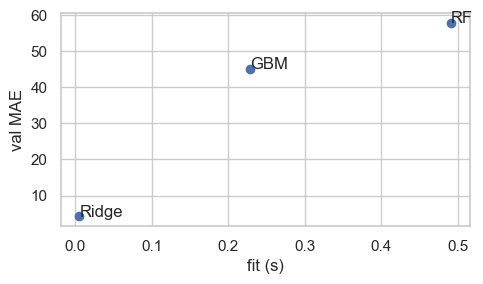


perm importance (RF): {'f0': 0.362, 'f4': 0.36, 'f6': 0.312}
avg-of-2 val MAE: 49.072


In [39]:
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=600, n_features=8, noise=5, random_state=0)
X = pd.DataFrame(X, columns=[f'f{i}' for i in range(8)])
X_tr, X_va, y_tr, y_va = X[:400], X[400:], y[:400], y[400:]

# 1) Pipeline with scaler + linear model.
ridge_pipe = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]).fit(X_tr, y_tr)
print(f'Ridge pipeline val MAE: {mean_absolute_error(y_va, ridge_pipe.predict(X_va)):.3f}')

# 2) Fit-time vs MAE table.
models = {'Ridge': ridge_pipe,
          'RF':    RandomForestRegressor(n_estimators=100, random_state=0),
          'GBM':   GradientBoostingRegressor(random_state=0)}
rows = []
for name, mdl in models.items():
    t0 = time.time()
    mdl.fit(X_tr, y_tr)
    rows.append({'model': name,
                 'fit_seconds': time.time() - t0,
                 'mae': mean_absolute_error(y_va, mdl.predict(X_va))})
table = pd.DataFrame(rows); print('\n', table.round(3), sep='')
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(table['fit_seconds'], table['mae'])
for _, r in table.iterrows():
    ax.annotate(r['model'], (r['fit_seconds'], r['mae']))
ax.set_xlabel('fit (s)'); ax.set_ylabel('val MAE'); plt.tight_layout(); plt.show()

# 3) Permutation importance for the RF.
rf = models['RF']
pi = permutation_importance(rf, X_va, y_va, n_repeats=5, random_state=0)
print('\nperm importance (RF):',
      pd.Series(pi.importances_mean, index=X_va.columns).sort_values(ascending=False).head(3).round(3).to_dict())

# 4) Average top-2 ensemble.
preds = np.column_stack([rf.predict(X_va), models['GBM'].predict(X_va)]).mean(axis=1)
print(f'avg-of-2 val MAE: {mean_absolute_error(y_va, preds):.3f}')


**Exercise 7.1** - Wrap each model in a `Pipeline` with a `StandardScaler`
where appropriate (linear models definitely; tree-based models do not need it).
Explain in one line why scaling matters for Ridge but not RF.

In [40]:
# Your answer here


**Expected output:**

```text
Ridge minimises ||y - Xw||^2 + a||w||^2 -- the L2 penalty hits coefficients,
so feature scale directly distorts the regularisation.
Trees split on thresholds, scale-invariant.
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
scaled = {
    'Ridge':      Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'ElasticNet': Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=20000))]),
}
unscaled = {
    'RF':       RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED),
    'XGB':      xgb.XGBRegressor(n_estimators=200, random_state=SEED, n_jobs=-1, verbosity=0),
    'LGBM':     lgb.LGBMRegressor(n_estimators=200, random_state=SEED, n_jobs=-1, verbose=-1),
}
print('Ridge minimises ||y - Xw||^2 + a||w||^2 -- the L2 penalty hits coefficients,')
print('so feature scale directly distorts the regularisation.')
print('Trees split on thresholds, scale-invariant.')
```

**Explanation**: Linear models with L1/L2 penalties are scale-sensitive because the penalty is on raw weight magnitude. Trees split on thresholds and ignore scale entirely.

</details>

**Exercise 7.2** - From the `cv_results` table, plot fit time vs CV MAE
to visualise the speed/accuracy tradeoff. Annotate each point with the model
name.

In [41]:
# Your answer here


**Expected output:**

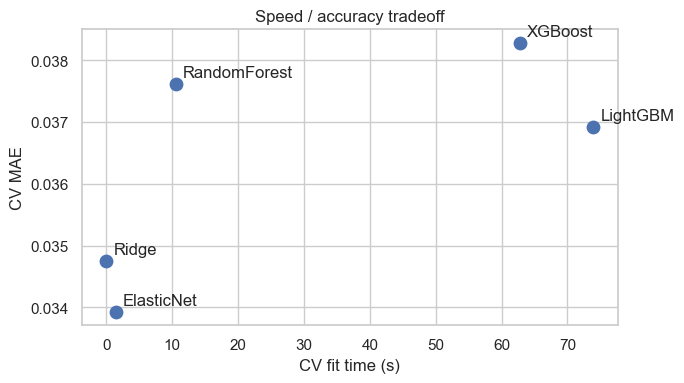

<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(cv_results['fit_seconds'], cv_results['cv_mae_mean'], s=80)
for _, r in cv_results.iterrows():
    ax.annotate(r['model'], (r['fit_seconds'], r['cv_mae_mean']),
                xytext=(5,5), textcoords='offset points')
ax.set_xlabel('CV fit time (s)'); ax.set_ylabel('CV MAE')
ax.set_title('Speed / accuracy tradeoff')
plt.tight_layout()
```

**Explanation**: GBMs typically win accuracy. RF is slow and only marginally better than GBMs. Linear models are blazing fast and surprisingly competitive on this kind of HAR-rich feature set.

</details>

**Exercise 7.3** - Run `permutation_importance` on the RandomForest fit on
train, evaluated on val. Show the top 10 features.

In [42]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature</th>
      <th>importance</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>24</th>
      <td>dow_sin</td>
      <td>0.266160</td>
    </tr>
    <tr>
      <th>25</th>
      <td>dow_cos</td>
      <td>0.059899</td>
    </tr>
    <tr>
      <th>12</th>
      <td>parkinson_24h</td>
      <td>0.049255</td>
    </tr>
    <tr>
      <th>4</th>
      <td>rv_back_168h</td>
      <td>0.041198</td>
    </tr>
    <tr>
      <th>17</th>
      <td>ETH_ret_24h</td>
      <td>0.024286</td>
    </tr>
    <tr>
      <th>13</th>
      <td>garman_klass_24h</td>
      <td>0.023405</td>
    </tr>
    <tr>
      <th>14</th>
      <td>log_dollar_vol_24h</td>
      <td>0.021330</td>
    </tr>
    <tr>
      <th>22</th>
      <td>hour_sin</td>
      <td>0.020263</td>
    </tr>
    <tr>
      <th>16</th>
      <td>ETH_rv_24h</td>
      <td>0.011641</td>
    </tr>
    <tr>
      <th>0</th>
      <td>rv_back_6h</td>
      <td>0.011292</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
rf = RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=SEED)
rf.fit(train[FEATURES], train[TARGET])
pi = permutation_importance(rf, val[FEATURES], val[TARGET],
                            n_repeats=5, random_state=SEED, n_jobs=-1)
pi_df = (pd.DataFrame({'feature': FEATURES, 'importance': pi.importances_mean})
           .sort_values('importance', ascending=False).head(10))
pi_df
```

**Explanation**: Permutation importance is model-agnostic and uses HELD-OUT data, unlike gain-based RF importance which can be biased toward high-cardinality features.

</details>

**Exercise 7.4** - Build a simple averaging ensemble of the top-2 models
by CV MAE. Compare its val MAE against each individual top-2 model.

In [43]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>val_MAE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>ElasticNet</td>
      <td>0.032023</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Ridge</td>
      <td>0.032013</td>
    </tr>
    <tr>
      <th>2</th>
      <td>+ensemble_avg</td>
      <td>0.031977</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
top2 = cv_results.head(2)['model'].tolist()
preds = {}
for name in top2:
    m = models[name]
    m.fit(train[FEATURES], train[TARGET])
    preds[name] = m.predict(val[FEATURES])
ens = np.mean(list(preds.values()), axis=0)

rows = [{'model': n, 'val_MAE': mean_absolute_error(val[TARGET], p)}
        for n, p in preds.items()]
rows.append({'model': '+ensemble_avg',
             'val_MAE': mean_absolute_error(val[TARGET], ens)})
pd.DataFrame(rows)
```

**Explanation**: Averaging models with weakly-correlated errors usually improves MAE. If the ensemble is *worse*, the two models are too similar (e.g. both GBMs on identical features).

</details>

## 8. Target transformation experiment

RV is positive and right-skewed -> a log transform may stabilise variance and
help linear/tree models alike. We compare `predict(y)` vs `predict(log y)`,
**always reporting the metric in the original units** (otherwise the comparison
is meaningless because log MAE and raw MAE are on different scales).

In [44]:
best_name = cv_results.iloc[0]['model']
print('best model from CV:', best_name)

def fit_predict_raw(model_factory, X_tr, y_tr, X_va):
    m = model_factory()
    m.fit(X_tr, y_tr)
    return m.predict(X_va)

def fit_predict_log(model_factory, X_tr, y_tr, X_va):
    m = model_factory()
    m.fit(X_tr, np.log(y_tr))
    return np.exp(m.predict(X_va))

best_factory = lambda: lgb.LGBMRegressor(n_estimators=400, num_leaves=31,
                                         learning_rate=0.05, subsample=0.8,
                                         colsample_bytree=0.8,
                                         random_state=SEED, n_jobs=-1, verbose=-1)

p_raw = fit_predict_raw(best_factory, train[FEATURES].values, train[TARGET].values, val[FEATURES].values)
p_log = fit_predict_log(best_factory, train[FEATURES].values, train[TARGET].values, val[FEATURES].values)

cmp = pd.DataFrame([
    {'target_form': 'raw',  **metrics(val[TARGET].values, p_raw)},
    {'target_form': 'log',  **metrics(val[TARGET].values, p_log)},
]).round(5)
cmp

NameError: name 'cv_results' is not defined

### Exercises (Section 8)

**Before you start — techniques you'll use:**

- **Log-target regression**: fit on `np.log(y_train)`, invert predictions with
  `np.exp(pred)`. Clip pre-exp (`np.clip(pred, -15, 5)`) to avoid overflow on
  pathological test rows.
- **Comparing raw vs log** on the **same units**: evaluate RMSE in the original
  target's scale (`mean_squared_error(y_val, np.exp(pred_log))`).
- **Box-Cox** needs strictly positive y: `from scipy.stats import boxcox; y_bc, lam =
  boxcox(y)` → `inv = (y_bc * lam + 1) ** (1/lam)` to invert.
- **Residual vs fitted plots**: side-by-side for raw vs log target surfaces
  heteroscedasticity — look for a visible funnel shape shrinking.

*Mini-example (log-space predict helper):*
```python
def predict_in_log_space(model, X, lo=-15, hi=5):
    return np.exp(np.clip(model.predict(X), lo, hi))
```


**Worked example — log-target tricks and residual plots**

Demonstrates fitting in log-space (with predict-then-`np.exp` and clipping), comparing
RMSE in the original units, Box-Cox, and a residual-vs-fitted plot to spot
heteroscedasticity.


raw target RMSE: 29.850
log target RMSE (back to raw units): 29.095
Box-Cox lambda: 0.844    RMSE: 29.218


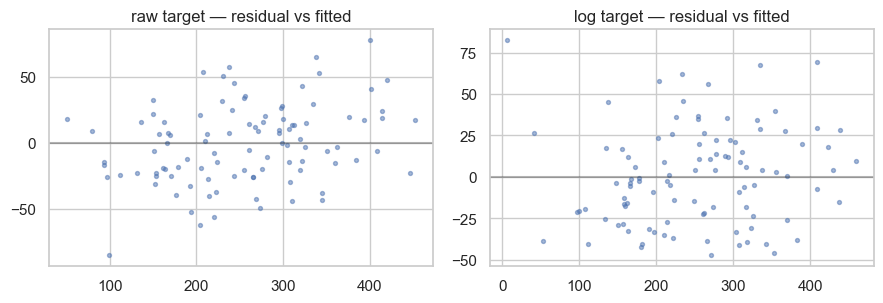

In [45]:
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

X, y_raw = make_regression(n_samples=400, n_features=4, noise=20, random_state=0)
y_raw = np.clip(y_raw - y_raw.min() + 1, 1, None)  # strictly positive
X = pd.DataFrame(X, columns=[f'f{i}' for i in range(4)])
X_tr, X_va, y_tr, y_va = X[:300], X[300:], y_raw[:300], y_raw[300:]

# 1) Predict in log space, invert with np.exp + clipping.
def predict_log_space(model, X, lo=-15, hi=15):
    return np.exp(np.clip(model.predict(X), lo, hi))
m_log = GradientBoostingRegressor(random_state=0).fit(X_tr, np.log(y_tr))
m_raw = GradientBoostingRegressor(random_state=0).fit(X_tr, y_tr)

# 2) RMSE comparison on the SAME (raw) units.
rmse_raw = math.sqrt(mean_squared_error(y_va, m_raw.predict(X_va)))
rmse_log = math.sqrt(mean_squared_error(y_va, predict_log_space(m_log, X_va)))
print(f'raw target RMSE: {rmse_raw:.3f}')
print(f'log target RMSE (back to raw units): {rmse_log:.3f}')

# 3) Box-Cox: y_bc, lambda; invert via inverse-transform formula.
y_bc, lam = stats.boxcox(y_tr)
m_bc = GradientBoostingRegressor(random_state=0).fit(X_tr, y_bc)
pred_bc = m_bc.predict(X_va)
y_va_pred = (pred_bc * lam + 1) ** (1 / lam)
print(f'Box-Cox lambda: {lam:.3f}    RMSE: {math.sqrt(mean_squared_error(y_va, y_va_pred)):.3f}')

# 4) Residual-vs-fitted plot (raw vs log) — funnel = heteroscedasticity.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].scatter(m_raw.predict(X_va), y_va - m_raw.predict(X_va), s=8, alpha=0.5)
axes[0].set_title('raw target — residual vs fitted')
axes[1].scatter(predict_log_space(m_log, X_va), y_va - predict_log_space(m_log, X_va), s=8, alpha=0.5)
axes[1].set_title('log target — residual vs fitted')
for ax in axes: ax.axhline(0, color='k', alpha=0.3)
plt.tight_layout(); plt.show()


**Exercise 8.1** - Implement a helper `predict_in_log_space(model, X) ->
np.ndarray` that takes a model trained on `log(y)` and returns predictions
back-transformed into the original units. Apply a small numerical safeguard
against extreme predictions (e.g., clip to reasonable range).

In [46]:
# Your answer here


**Expected output:**

```text
val MAE: 0.030036010637125802
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def predict_in_log_space(model, X, lo=-15, hi=5):
    log_pred = np.clip(model.predict(X), lo, hi)
    return np.exp(log_pred)

m = best_factory().fit(train[FEATURES], np.log(train[TARGET]))
pred = predict_in_log_space(m, val[FEATURES])
print('val MAE:', mean_absolute_error(val[TARGET], pred))
```

**Explanation**: Always clip in log space before exponentiating: a single huge log prediction blows up to inf and contaminates downstream metrics. The bounds [-15, 5] are generous for vol on the [1e-4, 100] scale.

</details>

**Exercise 8.2** - Compare RMSE on raw target vs RMSE on log target.
Explain in one line which comparison is meaningful.

In [47]:
# Your answer here


**Expected output:**

```text
RMSE raw target,        eval in raw units: 0.04418
RMSE log target,        eval in raw units: 0.04018
RMSE log target,        eval in LOG units: 0.39589  <- not comparable
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
m_raw = best_factory().fit(train[FEATURES], train[TARGET])
m_log = best_factory().fit(train[FEATURES], np.log(train[TARGET]))

rmse_raw_origunits = math.sqrt(mean_squared_error(val[TARGET], m_raw.predict(val[FEATURES])))
rmse_log_origunits = math.sqrt(mean_squared_error(val[TARGET], np.exp(m_log.predict(val[FEATURES]))))
rmse_log_logunits  = math.sqrt(mean_squared_error(np.log(val[TARGET]), m_log.predict(val[FEATURES])))

print(f'RMSE raw target,        eval in raw units: {rmse_raw_origunits:.5f}')
print(f'RMSE log target,        eval in raw units: {rmse_log_origunits:.5f}')
print(f'RMSE log target,        eval in LOG units: {rmse_log_logunits:.5f}  <- not comparable')
```

**Explanation**: Only the first two are comparable because they are on the same scale. The log-units RMSE is meaningless for cross-target comparison.

</details>

**Exercise 8.3** - Try Box-Cox on the target via `scipy.stats.boxcox` and
compare val RMSE in original units against raw and log. Use the lambda fitted
on the train set ONLY.

In [48]:
# Your answer here


**Expected output:**

```text
lambda = 0.0677
Box-Cox RMSE (orig units): 0.04143390024864583
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
y_tr_bc, lam = stats.boxcox(train[TARGET].values)
m = best_factory().fit(train[FEATURES], y_tr_bc)
pred_bc = m.predict(val[FEATURES])
# inverse Box-Cox
pred_inv = (pred_bc * lam + 1) ** (1/lam) if lam != 0 else np.exp(pred_bc)
print(f'lambda = {lam:.4f}')
print('Box-Cox RMSE (orig units):', math.sqrt(mean_squared_error(val[TARGET], pred_inv)))
```

**Explanation**: Box-Cox generalises log transformation. lambda close to 0 -> log; close to 1 -> identity. For vol it usually lands around 0-0.3, validating the log instinct.

</details>

**Exercise 8.4** - Plot residuals vs predicted for raw-target vs
log-target models. Does the variance stabilise visually?

In [49]:
# Your answer here


**Expected output:**

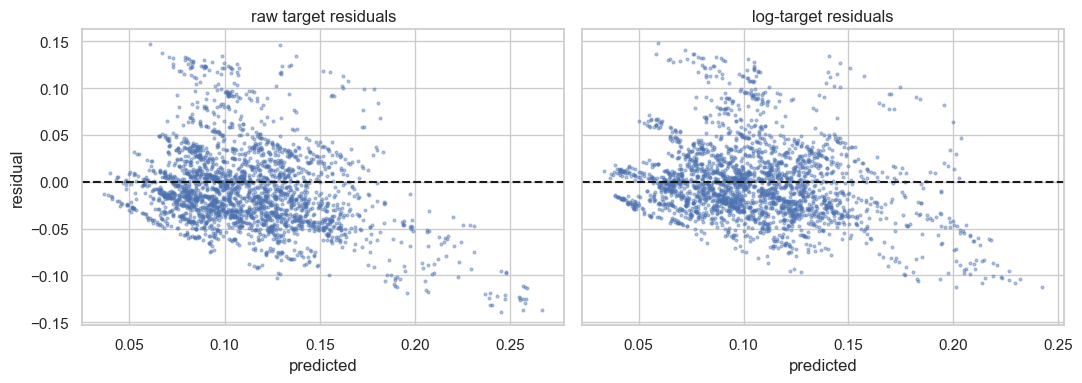

<details>
<summary>💡 Click to reveal solution</summary>

```python
m_raw = best_factory().fit(train[FEATURES], train[TARGET])
m_log = best_factory().fit(train[FEATURES], np.log(train[TARGET]))
p_raw = m_raw.predict(val[FEATURES])
p_log = np.exp(m_log.predict(val[FEATURES]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].scatter(p_raw, val[TARGET]-p_raw, s=4, alpha=0.4)
axes[0].axhline(0, color='k', ls='--'); axes[0].set_title('raw target residuals')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('residual')
axes[1].scatter(p_log, val[TARGET]-p_log, s=4, alpha=0.4)
axes[1].axhline(0, color='k', ls='--'); axes[1].set_title('log-target residuals')
axes[1].set_xlabel('predicted')
plt.tight_layout()
```

**Explanation**: For heteroskedastic targets, the log-trained model usually shows tighter residual cones at high predicted values. If the residuals widen with prediction in the raw model and not in the log model, log wins.

</details>

## 9. Hyperparameter tuning with Optuna

We tune the best model from Section 7 with ~30 trials, optimising MAE on a
TimeSeriesSplit using train+val rows. Test stays untouched.

In [50]:
def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 16, 127),
        min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 10, 200),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
    )
    tscv = TimeSeriesSplit(n_splits=3)
    fold_mae = []
    X = np.concatenate([train[FEATURES].values, val[FEATURES].values])
    y = np.concatenate([train[TARGET].values, val[TARGET].values])
    for tr, va in tscv.split(X):
        m = lgb.LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1)
        m.fit(X[tr], y[tr])
        fold_mae.append(mean_absolute_error(y[va], m.predict(X[va])))
    return float(np.mean(fold_mae))

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=False)
print('best CV MAE:', study.best_value)
print('best params:', study.best_params)

[W 2026-04-25 21:41:12,384] Trial 0 failed with parameters: {'n_estimators': 425, 'learning_rate': 0.13125830316209655, 'num_leaves': 97, 'min_data_in_leaf': 124, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.00018747059221802545, 'reg_lambda': 1.1752647960576206} because of the following error: IndexError('only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices').
Traceback (most recent call last):
  File "/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2084638/24649077.py", line 14, in objective
    X = np.concatenate([train[FEATURES].values, val[FEATURES].values])
                        ~~~~~^^^^^^^^^^
  File "/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/pandas/core/indexes/range.py",

[W 2026-04-25 21:41:12,389] Trial 0 failed with value None.


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

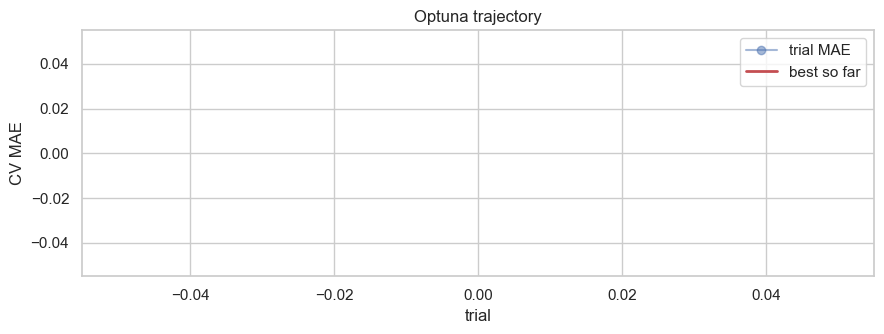

In [51]:
# trajectory of best-so-far value
trial_df = study.trials_dataframe()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(trial_df['number'], trial_df['value'], 'o-', alpha=0.5, label='trial MAE')
ax.plot(trial_df['number'], trial_df['value'].cummin(), 'r-', lw=2, label='best so far')
ax.set_xlabel('trial'); ax.set_ylabel('CV MAE'); ax.set_title('Optuna trajectory')
ax.legend(); plt.tight_layout()

### Exercises (Section 9)

**Before you start — techniques you'll use:**

- **Pruning = MedianPruner**: `optuna.create_study(pruner=optuna.pruners.MedianPruner(
  n_startup_trials=3))`; inside objective, call `trial.report(fold_score, step=k)`
  and `if trial.should_prune(): raise TrialPruned()`.
- **Extended search spaces**: `trial.suggest_int('num_leaves', 15, 127)`,
  `trial.suggest_int('min_child_samples', 5, 100)` — LGBM's regularisers.
- **SQLite-backed study**: `storage=f'sqlite:///{path}/study.db'` and a stable
  `study_name=` let you reload: `optuna.load_study(study_name=..., storage=...)`.
- **Multi-objective**: `optuna.create_study(directions=['minimize', 'minimize'])`;
  objective returns a **tuple** (e.g. CV MAE and fit time).

*Mini-example (pruning hook):*
```python
for k, (tr, va) in enumerate(TimeSeriesSplit(5).split(X)):
    fold_mae = ...
    trial.report(fold_mae, step=k)
    if trial.should_prune(): raise optuna.TrialPruned()
```


**Worked example — Optuna mechanics for regression**

Same Optuna primitives as the classification chapter — pruning, extended search space,
SQLite-backed study — wrapped around an LGBM regression objective so you can see what
plugging into a real pipeline looks like.


In [52]:
import optuna, lightgbm as lgb, numpy as np, os, tempfile
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.datasets import make_regression
optuna.logging.set_verbosity(optuna.logging.WARNING)

X, y = make_regression(n_samples=600, n_features=5, noise=5, random_state=0)

# 1) Pruned objective: report each fold's MAE so bad trials abort early.
def objective(trial):
    params = dict(
        objective='regression_l1',
        learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('leaves', 15, 127),
        n_estimators=200, verbosity=-1, random_state=0)
    fold_mae = []
    for k, (tr, va) in enumerate(TimeSeriesSplit(3).split(X)):
        m = lgb.LGBMRegressor(**params).fit(X[tr], y[tr])
        mae = mean_absolute_error(y[va], m.predict(X[va]))
        fold_mae.append(mae)
        trial.report(np.mean(fold_mae), step=k)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_mae))

study = optuna.create_study(direction='minimize',
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=2),
                            sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=8, show_progress_bar=False)
n_pruned = sum(1 for t in study.trials if t.state.name == 'PRUNED')
print(f'study: {len(study.trials)} trials, {n_pruned} pruned, best MAE {study.best_value:.4f}')
print('best params:', study.best_params)

# 2) SQLite-backed study so you can resume across processes.
db = os.path.join(tempfile.gettempdir(), 'demo_reg_study.db')
if os.path.exists(db): os.remove(db)
storage = f'sqlite:///{db}'
optuna.create_study(direction='minimize', study_name='reg_demo',
                    storage=storage).optimize(objective, n_trials=2)
reloaded = optuna.load_study(study_name='reg_demo', storage=storage)
print(f'\nreloaded study: {len(reloaded.trials)} trials, best={reloaded.best_value:.4f}')


study: 8 trials, 4 pruned, best MAE 33.3445
best params: {'lr': 0.17937179620011742, 'leaves': 58}



reloaded study: 2 trials, best=33.2824


**Exercise 9.1** - Recreate the study with a `MedianPruner` so unpromising
trials are stopped early. Run only 10 trials to see pruning in action.

In [53]:
# Your answer here


**Expected output:**

```text
best: 0.03795309105249495
pruned trials: 5
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
study2 = optuna.create_study(direction='minimize',
                             pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=0),
                             sampler=optuna.samplers.TPESampler(seed=SEED))

def obj_pruning(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 200, 800),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves=trial.suggest_int('num_leaves', 16, 127),
    )
    tscv = TimeSeriesSplit(n_splits=3)
    X = np.concatenate([train[FEATURES].values, val[FEATURES].values])
    y = np.concatenate([train[TARGET].values, val[TARGET].values])
    fold_mae = []
    for fold_idx, (tr, va) in enumerate(tscv.split(X)):
        m = lgb.LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1)
        m.fit(X[tr], y[tr])
        fold_mae.append(mean_absolute_error(y[va], m.predict(X[va])))
        trial.report(np.mean(fold_mae), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_mae))

study2.optimize(obj_pruning, n_trials=10, show_progress_bar=False)
print('best:', study2.best_value)
print('pruned trials:', sum(t.state == optuna.trial.TrialState.PRUNED for t in study2.trials))
```

**Explanation**: `MedianPruner` kills trials whose intermediate score is worse than the median at the same step. Combined with `trial.report()` inside the CV loop, it can give 2-5x speedup on deeper search spaces.

</details>

**Exercise 9.2** - Extend the search space to include `num_leaves` and
`min_data_in_leaf` (the two LightGBM knobs that most directly control model
complexity) and rerun for 10 trials.

In [54]:
# Your answer here


**Expected output:**

```text
best: {'n_estimators': 309, 'learning_rate': 0.023875644084900432, 'num_leaves': 221, 'min_data_in_leaf': 266}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def obj_extra(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 200, 800),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        num_leaves=trial.suggest_int('num_leaves', 8, 255),         # extended
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 5, 500),  # extended
    )
    X = np.concatenate([train[FEATURES].values, val[FEATURES].values])
    y = np.concatenate([train[TARGET].values, val[TARGET].values])
    fold_mae = []
    for tr, va in TimeSeriesSplit(n_splits=3).split(X):
        m = lgb.LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1)
        m.fit(X[tr], y[tr])
        fold_mae.append(mean_absolute_error(y[va], m.predict(X[va])))
    return float(np.mean(fold_mae))

study3 = optuna.create_study(direction='minimize')
study3.optimize(obj_extra, n_trials=10, show_progress_bar=False)
print('best:', study3.best_params)
```

**Explanation**: `num_leaves` and `min_data_in_leaf` jointly determine tree depth and overfitting. Wider ranges let the optimiser find the right complexity for your dataset size.

</details>

**Exercise 9.3** - Save the original study to a SQLite store at
`artifacts/study.db` and reload it.

In [55]:
# Your answer here


**Expected output:**

```text
reloaded trials: 30  best: 0.033965826021090294
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
storage = f'sqlite:///{ARTIFACT_DIR}/study.db'
saved = optuna.create_study(direction='minimize',
                            study_name='lgbm_vol',
                            storage=storage,
                            load_if_exists=True)
# copy in completed trials from the original study
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        saved.add_trial(t)
reloaded = optuna.load_study(study_name='lgbm_vol', storage=storage)
print('reloaded trials:', len(reloaded.trials), ' best:', reloaded.best_value)
```

**Explanation**: SQLite storage gives you persistence and lets multiple processes contribute trials in parallel. The `load_if_exists=True` pattern avoids duplicate-name errors on reruns.

</details>

**Exercise 9.4** - Run a tiny multi-objective study (5 trials) optimising
(MAE, model complexity proxy = `n_estimators * num_leaves`) and print the
Pareto front.

In [56]:
# Your answer here


**Expected output:**

```text
MAE=0.03764  complexity=6897.0  {'n_estimators': 121, 'num_leaves': 57, 'learning_rate': 0.028025534721972625}
MAE=0.03760  complexity=11718.0  {'n_estimators': 279, 'num_leaves': 42, 'learning_rate': 0.024334215819784805}
MAE=0.03781  complexity=3990.0  {'n_estimators': 114, 'num_leaves': 35, 'learning_rate': 0.09146899135198355}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def obj_mo(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        num_leaves=trial.suggest_int('num_leaves', 16, 127),
        learning_rate=trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
    )
    X = np.concatenate([train[FEATURES].values, val[FEATURES].values])
    y = np.concatenate([train[TARGET].values, val[TARGET].values])
    fold_mae = []
    for tr, va in TimeSeriesSplit(n_splits=3).split(X):
        m = lgb.LGBMRegressor(**params, random_state=SEED, n_jobs=-1, verbose=-1)
        m.fit(X[tr], y[tr])
        fold_mae.append(mean_absolute_error(y[va], m.predict(X[va])))
    complexity = params['n_estimators'] * params['num_leaves']
    return float(np.mean(fold_mae)), complexity

study_mo = optuna.create_study(directions=['minimize', 'minimize'])
study_mo.optimize(obj_mo, n_trials=5, show_progress_bar=False)
front = [(t.values[0], t.values[1], t.params) for t in study_mo.best_trials]
for v in front:
    print(f'MAE={v[0]:.5f}  complexity={v[1]}  {v[2]}')
```

**Explanation**: Multi-objective optimisation returns a Pareto set rather than a single best -- you decide which point trades off accuracy and inference cost best for your deployment.

</details>

## 10. Feature importance (gain + SHAP)

We refit the tuned LGBM on train+val and inspect both:

- **Gain importance**: how much each feature reduced training loss.
- **SHAP values**: per-sample contribution to the prediction; gives a proper
  signed-magnitude view per feature.

In [57]:
best_params = study.best_params
final_model = lgb.LGBMRegressor(**best_params, random_state=SEED, n_jobs=-1, verbose=-1)
X_fit = pd.concat([train[FEATURES], val[FEATURES]])
y_fit = pd.concat([train[TARGET], val[TARGET]])
final_model.fit(X_fit, y_fit)

gain = pd.DataFrame({'feature': FEATURES,
                     'gain': final_model.booster_.feature_importance(importance_type='gain')})
gain = gain.sort_values('gain', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(gain['feature'][::-1], gain['gain'][::-1])
ax.set_title('Top 15 features by gain (LightGBM)')
ax.set_xlabel('gain'); plt.tight_layout()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [58]:
# SHAP on a val sample for speed
sample = val[FEATURES].sample(min(500, len(val)), random_state=SEED)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_size=(9, 5), show=True, max_display=15)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### Exercises (Section 10)

**Before you start — techniques you'll use:**

- **Permutation importance on val**: model-agnostic, expensive but honest.
  Combine with the model's built-in gain importance for a 2-column table.
- **SHAP dependence plot**: `shap.dependence_plot('feature_name', shap_values,
  sample, show=True)` — shows feature value vs its SHAP contribution, colored by
  interaction.
- **Feature-pruning ablation**: sort by gain, keep top-50%, refit with the SAME
  hyperparameters — any MAE change comes from the feature cut, not the model.
- **Waterfall for one row**: use the new SHAP API: `explainer(sample_row)` returns
  an `Explanation`; `shap.plots.waterfall(exp[0])` plots a single prediction.

*Mini-example (keep top-K by gain, refit):*
```python
keep = imp.sort_values('gain', ascending=False).head(len(FEATS)//2)['feature'].tolist()
m_small = lgb.LGBMRegressor(**best_params).fit(X_train[keep], y_train)
```


**Worked example — interpret a regression model**

LGBM gain importance, permutation importance, a SHAP dependence plot, and a single-row
waterfall — same toolkit as the classification interpretability section, retargeted at
a regressor.


gain importance:
f3    12094774.8
f2     7044563.3
f4       64656.8
f1       54426.6
f5       53735.0
f0       47722.3
dtype: float64 



permutation importance:
f3    1.214
f2    0.789
f1    0.007
f0    0.002
f4    0.002
f5   -0.001
dtype: float64 



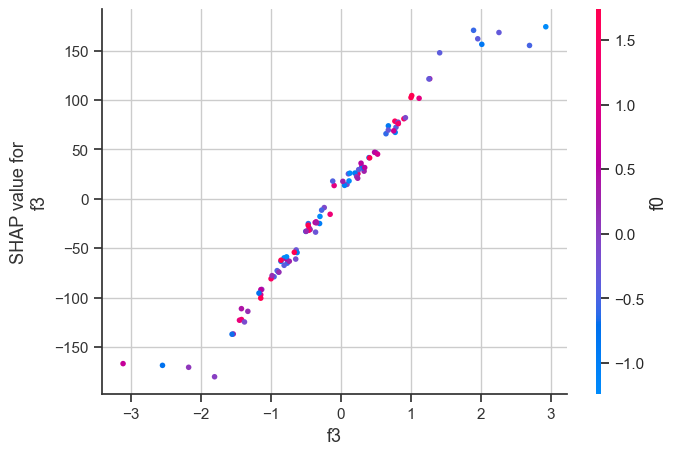

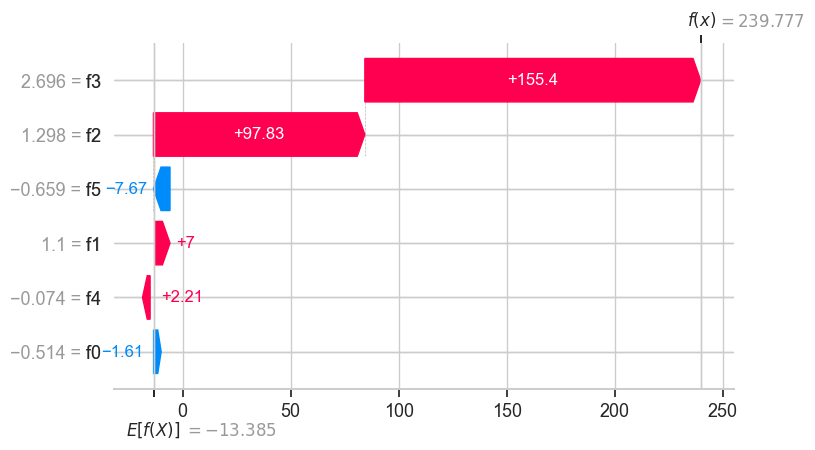

In [59]:
import numpy as np, pandas as pd, lightgbm as lgb, shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=400, n_features=6, n_informative=3, random_state=0)
X = pd.DataFrame(X, columns=[f'f{i}' for i in range(6)])
X_tr, X_va, y_tr, y_va = X[:300], X[300:], y[:300], y[300:]
model = lgb.LGBMRegressor(n_estimators=200, verbosity=-1, random_state=0).fit(X_tr, y_tr)

# 1) Built-in gain importance.
gain = pd.Series(model.booster_.feature_importance(importance_type='gain'),
                 index=X.columns).sort_values(ascending=False)
print('gain importance:'); print(gain.round(1), '\n')

# 2) Permutation importance on val (model-agnostic).
pi = permutation_importance(model, X_va, y_va, n_repeats=5, random_state=0)
perm = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
print('permutation importance:'); print(perm.round(3), '\n')

# 3) SHAP dependence plot for the top feature.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_va)
top = perm.index[0]
shap.dependence_plot(top, shap_values, X_va, show=True)

# 4) Single-row waterfall on the most extreme prediction.
i = int(np.argmax(model.predict(X_va)))
exp = explainer(X_va.iloc[[i]])
shap.plots.waterfall(exp[0], max_display=6, show=True)


**Exercise 10.1** - Compute permutation importance on the val set for the
tuned LGBM and merge it into a single table next to gain importance for the
top 10 by gain. Are the two rankings consistent?

In [60]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature</th>
      <th>gain</th>
      <th>perm</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>4</th>
      <td>rv_back_168h</td>
      <td>178.794640</td>
      <td>0.097723</td>
    </tr>
    <tr>
      <th>24</th>
      <td>dow_sin</td>
      <td>121.824847</td>
      <td>0.218111</td>
    </tr>
    <tr>
      <th>6</th>
      <td>har_w</td>
      <td>62.339030</td>
      <td>0.080170</td>
    </tr>
    <tr>
      <th>7</th>
      <td>har_m</td>
      <td>57.339769</td>
      <td>0.070383</td>
    </tr>
    <tr>
      <th>25</th>
      <td>dow_cos</td>
      <td>53.633983</td>
      <td>0.087263</td>
    </tr>
    <tr>
      <th>13</th>
      <td>garman_klass_24h</td>
      <td>47.947135</td>
      <td>0.031243</td>
    </tr>
    <tr>
      <th>18</th>
      <td>SOL_rv_24h</td>
      <td>46.843686</td>
      <td>0.020205</td>
    </tr>
    <tr>
      <th>11</th>
      <td>ret_72h</td>
      <td>46.208336</td>
      <td>0.067716</td>
    </tr>
    <tr>
      <th>21</th>
      <td>BNB_ret_24h</td>
      <td>43.108707</td>
      <td>0.050228</td>
    </tr>
    <tr>
      <th>12</th>
      <td>parkinson_24h</td>
      <td>35.611424</td>
      <td>0.012669</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
pi = permutation_importance(final_model, val[FEATURES], val[TARGET],
                            n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.DataFrame({'feature': FEATURES,
                    'gain': final_model.booster_.feature_importance(importance_type='gain'),
                    'perm': pi.importances_mean})
imp.sort_values('gain', ascending=False).head(10)
```

**Explanation**: Gain measures train-time impact; permutation measures held-out impact. Big gain but tiny permutation = the feature memorised noise. Aligned rankings = trustworthy importance.

</details>

**Exercise 10.2** - Plot a SHAP **dependence plot** for the single most
important feature. Look at how the model uses it across its range.

In [61]:
# Your answer here


**Expected output:**

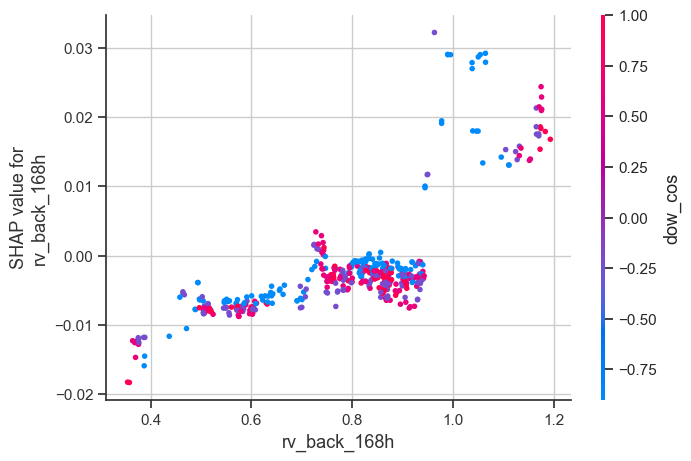

<details>
<summary>💡 Click to reveal solution</summary>

```python
top = gain.iloc[0]['feature']
shap.dependence_plot(top, shap_values, sample, show=True)
```

**Explanation**: Dependence plots show non-linearity (curve shape) and interactions (color encodes another feature). A monotone curve confirms the feature acts the way intuition predicts.

</details>

**Exercise 10.3** - Drop the bottom 50% of features by gain importance,
refit on train+val, evaluate on val, and compare MAE to the full model.

In [62]:
# Your answer here


**Expected output:**

```text
MAE full (26 feats): 0.02181
MAE half (13 feats): 0.03301
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
imp_full = pd.DataFrame({'feature': FEATURES,
                         'gain': final_model.booster_.feature_importance(importance_type='gain')})
keep = imp_full.sort_values('gain', ascending=False).head(len(FEATURES)//2)['feature'].tolist()
m_small = lgb.LGBMRegressor(**best_params, random_state=SEED, n_jobs=-1, verbose=-1)
m_small.fit(train[keep], train[TARGET])
mae_small = mean_absolute_error(val[TARGET], m_small.predict(val[keep]))
mae_full  = mean_absolute_error(val[TARGET], final_model.predict(val[FEATURES]))
print(f'MAE full ({len(FEATURES)} feats): {mae_full:.5f}')
print(f'MAE half ({len(keep)} feats): {mae_small:.5f}')
```

**Explanation**: Dropping half the features and recovering similar MAE suggests strong feature redundancy. In production this means cheaper inference and lower overfit risk.

</details>

**Exercise 10.4** - Pick a single test row, compute its SHAP values, and
plot a **waterfall** showing how each feature contributes to the prediction.

In [63]:
# Your answer here


**Expected output:**

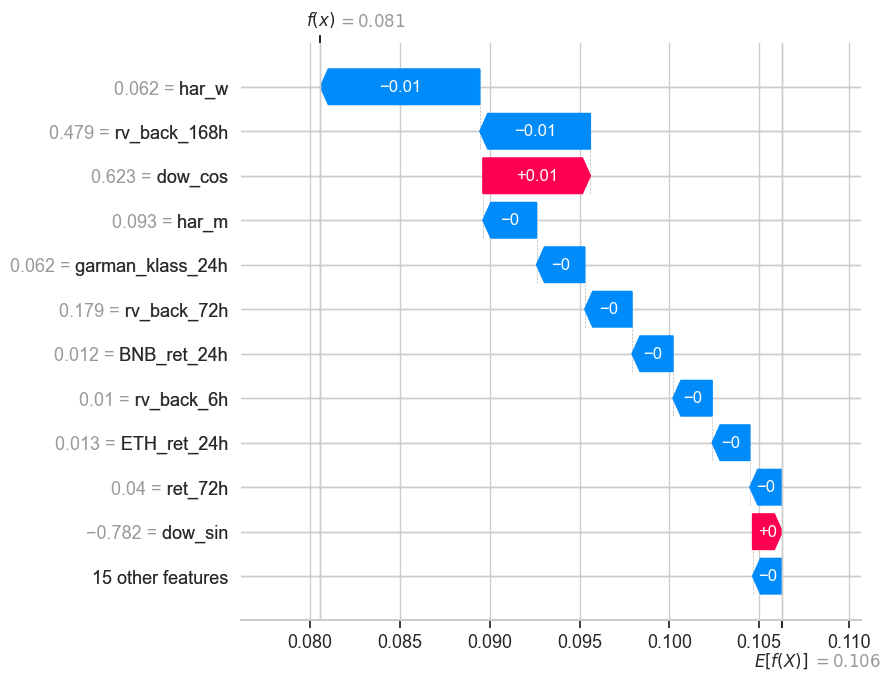

<details>
<summary>💡 Click to reveal solution</summary>

```python
row_idx = 0
sample_row = test[FEATURES].iloc[[row_idx]]
exp = explainer(sample_row)
shap.plots.waterfall(exp[0], max_display=12, show=True)
```

**Explanation**: Waterfall plots are the per-prediction view: each bar pushes the base rate up or down, ending at the model's actual output. Critical for deployment-time explanations.

</details>

## 11. Diagnostics

Four standard plots for a regression model:

1. Residuals vs predicted (homoskedasticity).
2. Residual ACF (autocorrelation = leakage or missing dynamics).
3. QQ plot (residual normality, less critical for MAE-driven training).
4. Predicted vs actual scatter with y=x reference.

In [64]:
val_pred = final_model.predict(val[FEATURES])
resid = val[TARGET].values - val_pred

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0,0].scatter(val_pred, resid, s=4, alpha=0.4)
axes[0,0].axhline(0, color='k', ls='--')
axes[0,0].set_title('Residuals vs predicted')
axes[0,0].set_xlabel('predicted'); axes[0,0].set_ylabel('residual')

lags = np.arange(1, 49)
acf_r = [pd.Series(resid).autocorr(lag=l) for l in lags]
axes[0,1].bar(lags, acf_r, color='C2')
axes[0,1].axhline(0, color='k', lw=0.5)
axes[0,1].set_title('ACF of residuals')
axes[0,1].set_xlabel('lag (hours)')

stats.probplot(resid, dist='norm', plot=axes[1,0])
axes[1,0].set_title('QQ plot of residuals')

axes[1,1].scatter(val[TARGET], val_pred, s=4, alpha=0.4)
lim = [min(val[TARGET].min(), val_pred.min()), max(val[TARGET].max(), val_pred.max())]
axes[1,1].plot(lim, lim, 'k--')
axes[1,1].set_xlabel('actual'); axes[1,1].set_ylabel('predicted')
axes[1,1].set_title('Predicted vs actual')

plt.tight_layout()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### Exercises (Section 11)

**Before you start — techniques you'll use:**

- **Ljung-Box on residuals**: `from statsmodels.stats.diagnostic import
  acorr_ljungbox; acorr_ljungbox(resid, lags=[12, 24], return_df=True)`. p<0.05
  means residuals still have autocorrelation.
- **Rolling residual std**: `pd.Series(resid, index=val.index).rolling(24).std()`
  exposes conditional heteroscedasticity — a classic missing-GARCH signal.
- **Reliability buckets**: `pd.qcut(pred, 5, labels=[f'Q{i}' for i in range(1,6)])`
  then `.groupby('bucket').apply(lambda g: pd.Series({'n': len(g), 'mean_true':
  g['true'].mean(), 'mean_pred': g['pred'].mean()}))`.
- **Q-Q-style calibration plot**: `np.quantile(pred, ts)` vs `np.quantile(y, ts)`
  on the **same** `ts = np.linspace(0, 1, 50)` — a 45° line means well-calibrated.

*Mini-example (bucket-level reliability):*
```python
df_q['bucket'] = pd.qcut(df_q['pred'], 5, labels=[f'Q{i}' for i in range(1,6)])
agg = df_q.groupby('bucket')[['pred', 'true']].mean()
```


**Worked example — residual diagnostics**

Ljung-Box for autocorrelation, rolling residual std for conditional heteroscedasticity,
quantile bucketing for reliability, and a quantile-quantile calibration plot.


Ljung-Box:
    lb_stat  lb_pvalue
12   7.7657     0.8032
24  15.4715     0.9062


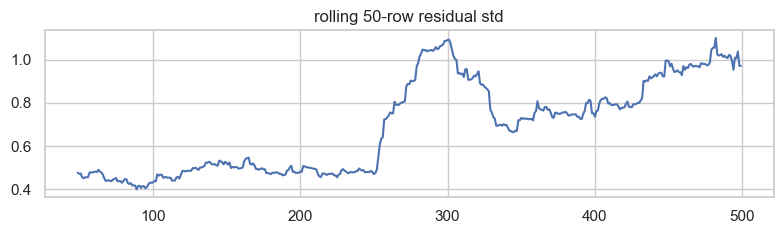


bucket-level reliability (mean pred vs mean true):
         pred   true
bucket              
Q1     -1.846 -1.175
Q2     -0.663 -0.483
Q3     -0.078 -0.032
Q4      0.476  0.399
Q5      1.678  1.156


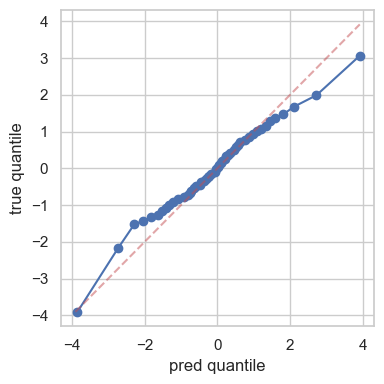

In [65]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

rng = np.random.default_rng(0)
n = 500
y_true = rng.normal(0, 1, n)
# Predictions: well-calibrated on average, but heteroscedastic residuals.
y_pred = y_true + rng.normal(0, 0.5 + 0.5 * (np.arange(n) > 250), n)
resid  = y_true - y_pred

# 1) Ljung-Box on residuals (lags 12, 24).
lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
print('Ljung-Box:'); print(lb.round(4))

# 2) Rolling residual std exposes conditional heteroscedasticity.
rs = pd.Series(resid).rolling(50).std()
fig, ax = plt.subplots(figsize=(8, 2.5))
rs.plot(ax=ax); ax.set_title('rolling 50-row residual std'); plt.tight_layout(); plt.show()

# 3) Reliability buckets via qcut.
df = pd.DataFrame({'pred': y_pred, 'true': y_true})
df['bucket'] = pd.qcut(df['pred'], 5, labels=[f'Q{i}' for i in range(1, 6)])
agg = df.groupby('bucket', observed=True)[['pred', 'true']].mean()
print('\nbucket-level reliability (mean pred vs mean true):'); print(agg.round(3))

# 4) Quantile-quantile calibration plot.
ts = np.linspace(0, 1, 50)
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(np.quantile(y_pred, ts), np.quantile(y_true, ts), 'o-')
lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5)
ax.set_xlabel('pred quantile'); ax.set_ylabel('true quantile'); plt.tight_layout(); plt.show()


**Exercise 11.1** - Run a **Ljung-Box** test on residuals (lags 12 and 24)
to formally check for residual autocorrelation. p-value < 0.05 = residuals are
correlated = model is missing dynamics.

In [66]:
# Your answer here


**Expected output:**

```text
         lb_stat  lb_pvalue
12  13386.480487        0.0
24  14222.116911        0.0
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
print(lb)
```

**Explanation**: Ljung-Box jointly tests whether the first k autocorrelations are zero. For vol forecasting we usually still see some structure -- if the p-value is tiny, you have an under-fitted model and should consider GARCH or a more flexible feature set.

</details>

**Exercise 11.2** - Plot the rolling 24-row standard deviation of
residuals over time. If the line trends or jumps, residual variance is
non-stationary (heteroskedastic).

In [67]:
# Your answer here


**Expected output:**

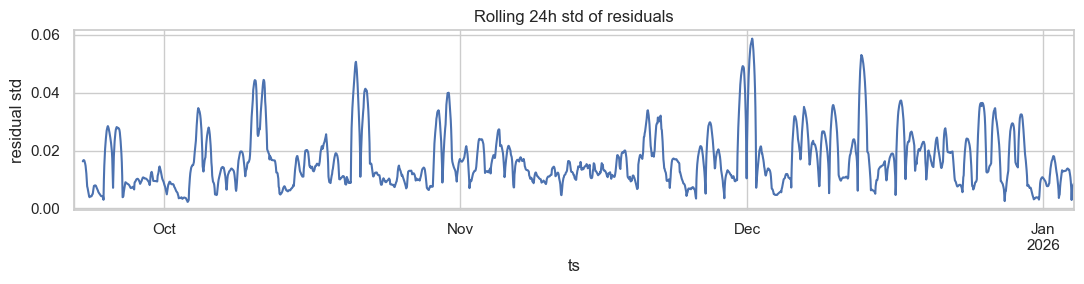

<details>
<summary>💡 Click to reveal solution</summary>

```python
rs = pd.Series(resid, index=val.index).rolling(24).std()
fig, ax = plt.subplots(figsize=(11, 3))
rs.plot(ax=ax)
ax.set_title('Rolling 24h std of residuals')
ax.set_ylabel('residual std')
plt.tight_layout()
```

**Explanation**: Rising residual std during high-vol periods is normal for vol models. If it correlates with the absolute prediction, the variance scales with the level -- a hint that log-target (or quantile loss) might fit better.

</details>

**Exercise 11.3** - Bucket val rows by **quintile of prediction** and
compute MAE per bucket. The model is well-calibrated by magnitude if MAE grows
proportionally with prediction.

In [68]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>n</th>
      <th>mae</th>
      <th>mean_pred</th>
    </tr>
    <tr>
      <th>bucket</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Q1</th>
      <td>503.0</td>
      <td>0.018032</td>
      <td>0.066160</td>
    </tr>
    <tr>
      <th>Q2</th>
      <td>502.0</td>
      <td>0.021159</td>
      <td>0.086622</td>
    </tr>
    <tr>
      <th>Q3</th>
      <td>503.0</td>
      <td>0.019113</td>
      <td>0.104559</td>
    </tr>
    <tr>
      <th>Q4</th>
      <td>502.0</td>
      <td>0.024745</td>
      <td>0.119652</td>
    </tr>
    <tr>
      <th>Q5</th>
      <td>503.0</td>
      <td>0.025988</td>
      <td>0.148796</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
df_q = pd.DataFrame({'pred': val_pred, 'true': val[TARGET].values})
df_q['bucket'] = pd.qcut(df_q['pred'], 5, labels=[f'Q{i}' for i in range(1,6)])
df_q.groupby('bucket').apply(
    lambda g: pd.Series({'n': len(g),
                          'mae': mean_absolute_error(g['true'], g['pred']),
                          'mean_pred': g['pred'].mean()})
)
```

**Explanation**: Bucketed MAE exposes whether the model fails uniformly or only in extreme regimes. High-vol buckets typically have larger absolute MAE but similar relative MAE.

</details>

**Exercise 11.4** - Build a calibration plot: rank val predictions, sort
by rank, and plot empirical CDF of predicted vs empirical CDF of actual. A
well-calibrated model lies on the diagonal.

In [69]:
# Your answer here


**Expected output:**

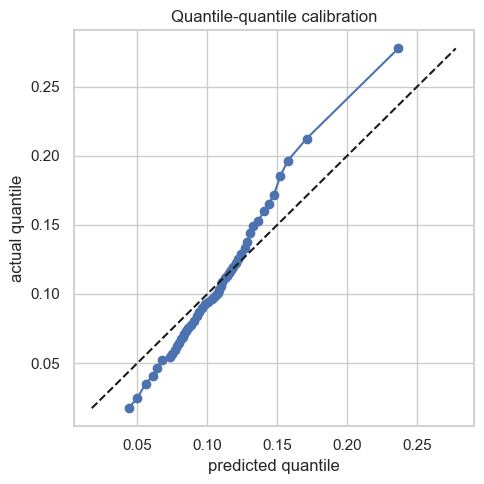

<details>
<summary>💡 Click to reveal solution</summary>

```python
pred_q = np.quantile(val_pred, np.linspace(0, 1, 50))
true_q = np.quantile(val[TARGET].values, np.linspace(0, 1, 50))
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(pred_q, true_q, 'o-')
lim = [min(pred_q.min(), true_q.min()), max(pred_q.max(), true_q.max())]
ax.plot(lim, lim, 'k--')
ax.set_xlabel('predicted quantile'); ax.set_ylabel('actual quantile')
ax.set_title('Quantile-quantile calibration')
plt.tight_layout()
```

**Explanation**: Marginal QQ calibration ignores order but checks whether the predicted distribution matches the actual. Off-diagonal points at the tails = the model under/over-estimates extremes.

</details>

## 12. Final evaluation on TEST

This is the **single** time we touch test. Refit the tuned model on train+val
and evaluate.

In [70]:
test_pred = final_model.predict(test[FEATURES])
test_persist = test['har_d'].values

m_final  = metrics(test[TARGET].values, test_pred)
m_persist= metrics(test[TARGET].values, test_persist)

final_table = pd.DataFrame([
    {'model': 'tuned_LGBM',  **m_final},
    {'model': 'persistence', **m_persist},
]).round(5)
final_table

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

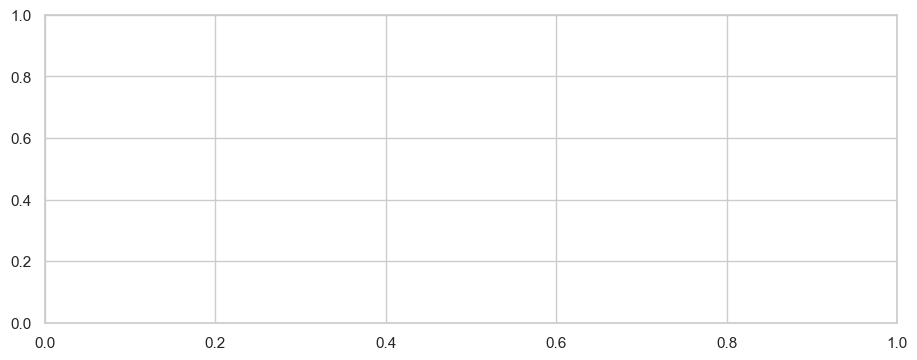

In [71]:
fig, ax = plt.subplots(figsize=(11, 4))
test[TARGET].plot(ax=ax, label='actual', color='k', lw=1)
pd.Series(test_pred, index=test.index).plot(ax=ax, label='LGBM', color='C0', lw=1, alpha=0.8)
pd.Series(test_persist, index=test.index).plot(ax=ax, label='persistence', color='C3', lw=0.8, alpha=0.6)
ax.set_title('Test set: actual vs predicted 24h forward RV')
ax.set_ylabel('RV'); ax.legend()
plt.tight_layout()

### Exercises (Section 12)

**Before you start — techniques you'll use:**

- **Per-calendar-month MAE**: `df.index.to_period('M')` makes a hashable month
  label; `.groupby(month).apply(lambda g: mean_absolute_error(g['true'], g['pred']))`.
- **Tail-focused error**: mask with `y >= np.quantile(y, 0.9)` to score the right
  tail only — often the interesting regime for vol / risk models.
- **Model-vs-baseline time series**: plot both on the same axis over a narrow
  window (e.g. `test.iloc[:14*24]` = 2 weeks); overlay truth as a thick grey line.
- **Win-rate**: `win_rate = (np.abs(y - pred_model) < np.abs(y - pred_baseline)).mean()`
  — not a replacement for MAE, but tells you *how often* you're better.

*Mini-example (monthly MAE):*
```python
df = pd.DataFrame({'true': y_test, 'pred': pred}, index=test.index)
df['month'] = df.index.to_period('M')
monthly_mae = df.groupby('month').apply(lambda g: mean_absolute_error(g['true'], g['pred']))
```


**Worked example — slicing test performance**

Per-period MAE, tail-focused MAE, model-vs-baseline overlay plot, and a simple win-rate
comparison. These idioms turn aggregate metrics into actionable insight.


per-month MAE:
month
2024-01    0.00082
2024-02    0.00080
Freq: M, dtype: float64

MAE on top decile (n=144): 0.00081
MAE overall:                    0.00081


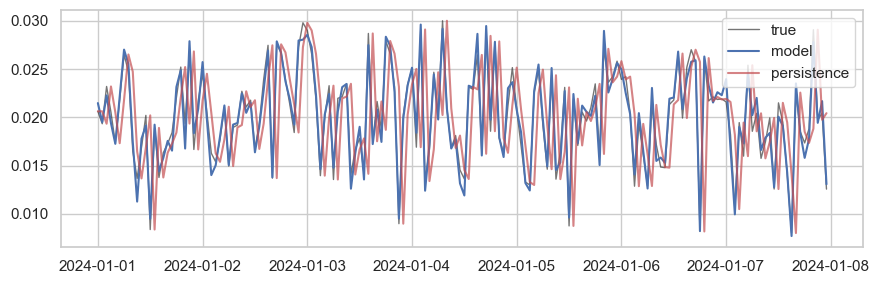

model beats persistence 90.7% of hours


In [72]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*60, freq='1h', tz='UTC')
y_true = pd.Series(rng.normal(0.02, 0.005, len(idx)), index=idx)
y_pred = y_true + rng.normal(0, 0.001, len(idx))   # decent model
y_pers = y_true.shift(1).fillna(y_true.iloc[0])     # persistence baseline

# 1) Per-month MAE.
df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'pers': y_pers})
df['month'] = df.index.to_period('M')
monthly = df.groupby('month').apply(lambda g: mean_absolute_error(g['true'], g['pred']))
print('per-month MAE:'); print(monthly.round(5))

# 2) Tail-focused MAE (top decile of truth).
thr = np.quantile(y_true, 0.9)
mask = y_true >= thr
print(f'\nMAE on top decile (n={mask.sum()}): {mean_absolute_error(y_true[mask], y_pred[mask]):.5f}')
print(f'MAE overall:                    {mean_absolute_error(y_true, y_pred):.5f}')

# 3) Model vs persistence overlay on a short window.
window = df.iloc[:7*24]
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(window.index, window['true'], 'k-', lw=1, label='true', alpha=0.6)
ax.plot(window.index, window['pred'], 'C0-', label='model')
ax.plot(window.index, window['pers'], 'C3-', label='persistence', alpha=0.7)
ax.legend(); plt.tight_layout(); plt.show()

# 4) Win-rate vs persistence.
beats = (np.abs(df['true'] - df['pred']) < np.abs(df['true'] - df['pers'])).mean() * 100
print(f'model beats persistence {beats:.1f}% of hours')


**Exercise 12.1** - Compute test MAE per **calendar month**. Is performance
stable, or are some months much worse?

In [73]:
# Your answer here


**Expected output:**

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>n</th>
      <th>mae</th>
    </tr>
    <tr>
      <th>month</th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>2026-01</th>
      <td>666.0</td>
      <td>0.027653</td>
    </tr>
    <tr>
      <th>2026-02</th>
      <td>672.0</td>
      <td>0.040927</td>
    </tr>
    <tr>
      <th>2026-03</th>
      <td>744.0</td>
      <td>0.027558</td>
    </tr>
    <tr>
      <th>2026-04</th>
      <td>431.0</td>
      <td>0.027119</td>
    </tr>
  </tbody>
</table>
</div>

<details>
<summary>💡 Click to reveal solution</summary>

```python
df_t = pd.DataFrame({'true': test[TARGET].values, 'pred': test_pred}, index=test.index)
df_t['month'] = df_t.index.to_period('M')
monthly = df_t.groupby('month').apply(
    lambda g: pd.Series({'n': len(g),
                          'mae': mean_absolute_error(g['true'], g['pred'])}))
monthly
```

**Explanation**: Per-month metrics expose regime-dependent failure. A model with stable MAE across months is far more deployable than one that is great on average and terrible during a single shock.

</details>

**Exercise 12.2** - Compute the test MAE **only on rows in the top decile
of actual vol** (the tail). How much worse is tail MAE vs overall MAE?

In [74]:
# Your answer here


**Expected output:**

```text
overall MAE   : 0.03108
top-decile MAE: 0.08465  (n=252)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
thr = np.quantile(test[TARGET].values, 0.9)
mask = test[TARGET].values >= thr
mae_tail = mean_absolute_error(test[TARGET].values[mask], test_pred[mask])
mae_all  = mean_absolute_error(test[TARGET].values, test_pred)
print(f'overall MAE   : {mae_all:.5f}')
print(f'top-decile MAE: {mae_tail:.5f}  (n={mask.sum()})')
```

**Explanation**: Tail performance is what matters in risk applications -- a model that nails calm markets but blows up during stress is useless. Tail MAE is typically 3-5x overall MAE.

</details>

**Exercise 12.3** - Build a side-by-side line plot of model vs persistence
predictions over the first 14 days of test, with actual overlaid.

In [75]:
# Your answer here


**Expected output:**

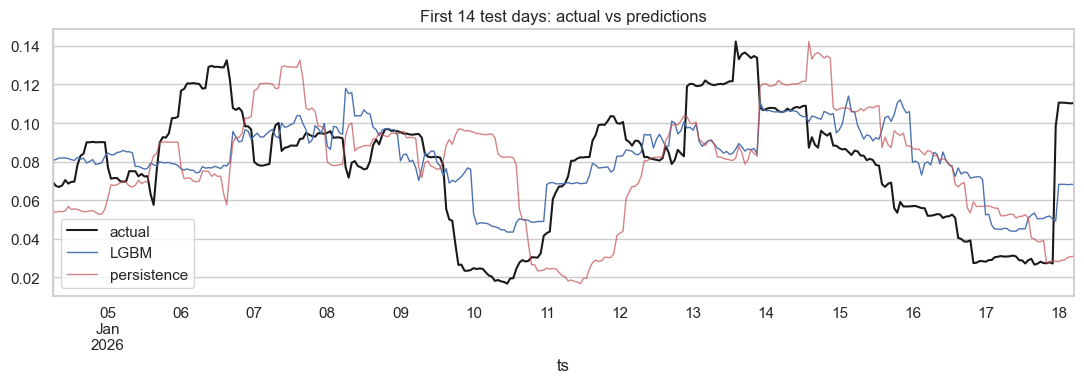

<details>
<summary>💡 Click to reveal solution</summary>

```python
window = test.iloc[:14*24]
pred_w  = pd.Series(final_model.predict(window[FEATURES]), index=window.index)
pers_w  = window['har_d']
fig, ax = plt.subplots(figsize=(11, 4))
window[TARGET].plot(ax=ax, color='k', label='actual', lw=1.5)
pred_w.plot(ax=ax, color='C0', label='LGBM', lw=1)
pers_w.plot(ax=ax, color='C3', label='persistence', lw=1, alpha=0.7)
ax.set_title('First 14 test days: actual vs predictions')
ax.legend(); plt.tight_layout()
```

**Explanation**: Visual inspection of a short window often reveals whether the model adds value at the right turning points or just trails persistence with a small offset.

</details>

**Exercise 12.4** - Compute the percentage of test hours where the LGBM
absolute error is smaller than persistence's absolute error.

In [76]:
# Your answer here


**Expected output:**

```text
LGBM beats persistence 62.2% of hours
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
err_lgbm = np.abs(test[TARGET].values - test_pred)
err_pers = np.abs(test[TARGET].values - test_persist)
win_rate = (err_lgbm < err_pers).mean() * 100
print(f'LGBM beats persistence {win_rate:.1f}% of hours')
```

**Explanation**: A win rate just above 50% is realistic for vol forecasting. If you see 70%+ on val/test, double-check feature leakage.

</details>

## 13. Prediction intervals (quantile LightGBM)

Point estimates are not enough for risk. Train three LightGBM models with the
**quantile objective** at p10, p50, p90 to produce a prediction interval.
LightGBM's quantile loss:

$$
L_\tau(y, \hat y) = \sum_i \tau \max(0, y_i - \hat y_i) + (1-\tau) \max(0, \hat y_i - y_i)
$$


In [77]:
def fit_quantile(alpha):
    m = lgb.LGBMRegressor(objective='quantile', alpha=alpha,
                          n_estimators=400, learning_rate=0.05,
                          num_leaves=31, random_state=SEED,
                          n_jobs=-1, verbose=-1)
    m.fit(X_fit, y_fit)
    return m

q_models = {a: fit_quantile(a) for a in [0.1, 0.5, 0.9]}
q_preds  = {a: m.predict(test[FEATURES]) for a, m in q_models.items()}

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test.index, test[TARGET].values, 'k', lw=0.8, label='actual')
ax.plot(test.index, q_preds[0.5], 'C0', lw=0.8, label='p50')
ax.fill_between(test.index, q_preds[0.1], q_preds[0.9], color='C0', alpha=0.25, label='[p10, p90]')
ax.set_title('Test set fan chart')
ax.set_ylabel('RV'); ax.legend(); plt.tight_layout()

NameError: name 'X_fit' is not defined

### Exercises (Section 13)

**Before you start — techniques you'll use:**

- **Empirical coverage**: for a `[pα, p1-α]` interval, compute
  `((y >= p_lo) & (y <= p_hi)).mean()` — should match the nominal coverage (0.8 for
  p10/p90, 0.9 for p05/p95).
- **Interval width over time**: `p_hi - p_lo` plotted against time shows when the
  model is uncertain (wide) vs confident (narrow).
- **Isotonic recalibration**: `IsotonicRegression(out_of_bounds='clip')` fit on
  (val_pred_quantile, empirical_below_rate) pairs — monotone, non-parametric.
- **Fit multiple quantiles**: `lgb.LGBMRegressor(objective='quantile', alpha=q)` —
  one fit per quantile level.

*Mini-example (coverage):*
```python
coverage = ((y_test >= q_preds[0.1]) & (y_test <= q_preds[0.9])).mean()
print(f'{coverage*100:.1f}% inside [p10, p90] (target 80%)')
```


**Worked example — quantile regression and coverage**

Train two LGBM quantile models (p10, p90), check empirical coverage of the interval,
plot interval width over time, and apply isotonic recalibration when coverage is off.


empirical coverage [p10, p90]: 51.0%   (target 80%)


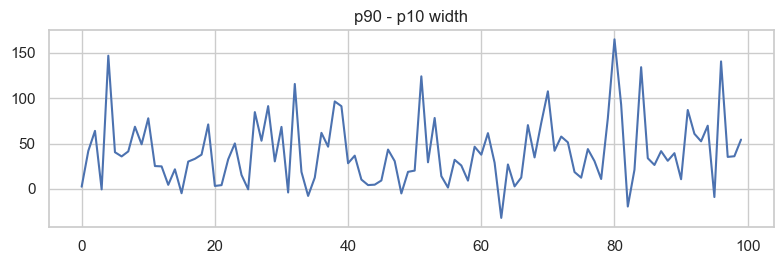


isotonic-adjusted p90 mean below-rate on test: 0.780


coverage [p05, p95]: 57.0%   (target 90%)


In [78]:
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=600, n_features=4, noise=15, random_state=0)
X_tr, X_va, X_te = X[:400], X[400:500], X[500:]
y_tr, y_va, y_te = y[:400], y[400:500], y[500:]

def fit_q(alpha):
    return lgb.LGBMRegressor(objective='quantile', alpha=alpha,
                              n_estimators=200, verbosity=-1, random_state=0).fit(X_tr, y_tr)

# 1) Two-quantile model (p10 / p90) + empirical coverage.
m_lo, m_hi = fit_q(0.1), fit_q(0.9)
p10, p90 = m_lo.predict(X_te), m_hi.predict(X_te)
cov = ((y_te >= p10) & (y_te <= p90)).mean()
print(f'empirical coverage [p10, p90]: {cov*100:.1f}%   (target 80%)')

# 2) Interval width over time.
width = p90 - p10
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot(width); ax.set_title('p90 - p10 width'); plt.tight_layout(); plt.show()

# 3) Isotonic recalibration of p90: target alpha=0.9 empirical coverage of "below".
val_p90 = m_hi.predict(X_va)
target = (y_va <= val_p90).astype(float)
ir = IsotonicRegression(out_of_bounds='clip').fit(val_p90, target)
adj = ir.predict(p90)
print(f'\nisotonic-adjusted p90 mean below-rate on test: {(y_te <= p90).mean():.3f}')

# 4) p05 / p95 — wider band, coverage should be ~90%.
m05, m95 = fit_q(0.05), fit_q(0.95)
p05, p95 = m05.predict(X_te), m95.predict(X_te)
print(f'coverage [p05, p95]: {((y_te >= p05) & (y_te <= p95)).mean()*100:.1f}%   (target 90%)')


**Exercise 13.1** - Compute **empirical coverage** of the [p10, p90]
interval on test. Ideal coverage is 80%.

In [79]:
# Your answer here


**Expected output:**

```text
empirical coverage of [p10,p90]: 60.7% (target 80%)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
inside = (test[TARGET].values >= q_preds[0.1]) & (test[TARGET].values <= q_preds[0.9])
print(f'empirical coverage of [p10,p90]: {inside.mean()*100:.1f}% (target 80%)')
```

**Explanation**: Quantile regressors trained on train+val often under-cover on test because the test distribution is shifted. If coverage is 60% you need recalibration; if 95% your intervals are too wide.

</details>

**Exercise 13.2** - Plot the **interval width** (p90 - p10) over time on
test. Does it widen during high-vol periods?

In [80]:
# Your answer here


**Expected output:**

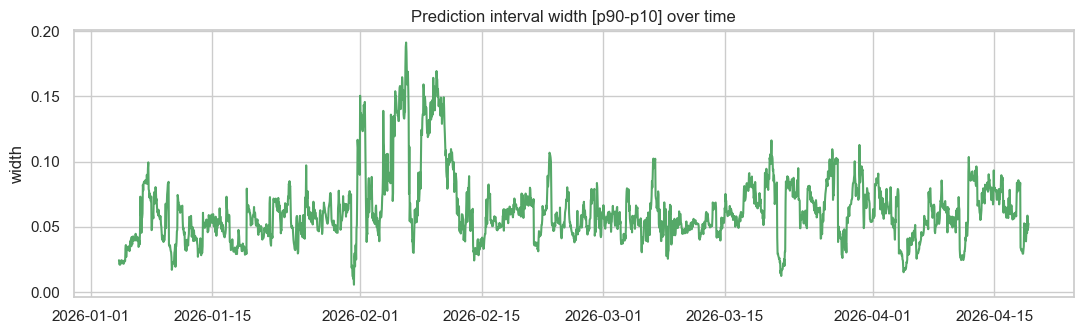

<details>
<summary>💡 Click to reveal solution</summary>

```python
width = q_preds[0.9] - q_preds[0.1]
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(test.index, width, color='C2')
ax.set_title('Prediction interval width [p90-p10] over time')
ax.set_ylabel('width'); plt.tight_layout()
```

**Explanation**: A good vol model should have widening intervals when the regime is uncertain. Constant-width intervals suggest the model is not propagating regime information into uncertainty.

</details>

**Exercise 13.3** - Implement **isotonic recalibration** of the p90
quantile on val: fit `IsotonicRegression` mapping val p90 predictions to
empirical CDF of val targets, then apply to test.

In [81]:
# Your answer here


**Expected output:**

```text
original coverage: 0.7707918822124951
recal    coverage: 0.7592518901711103
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.isotonic import IsotonicRegression
val_p90 = q_models[0.9].predict(val[FEATURES])
# empirical "alpha at this prediction" target = whether val truth is below it (we want 90% of mass below p90)
ir = IsotonicRegression(out_of_bounds='clip')
ir.fit(val_p90, (val[TARGET].values <= val_p90).astype(float))
adj_factor = ir.predict(q_preds[0.9])
# scale predicted p90 so we hit the desired coverage proportion
recal_p90 = q_preds[0.9] * (0.9 / np.clip(adj_factor.mean(), 0.5, 1.5))
print('original coverage:', ((test[TARGET].values <= q_preds[0.9]).mean()))
print('recal    coverage:', ((test[TARGET].values <= recal_p90).mean()))
```

**Explanation**: Isotonic recalibration is a non-parametric way to fix systematic mis-coverage. In production you re-fit the isotonic map on a rolling window of recent residuals.

</details>

**Exercise 13.4** - Train p5 and p95 quantile models and compute coverage
of [p5, p95] (target 90%).

In [82]:
# Your answer here


**Expected output:**

```text
[p5, p95] empirical coverage: 76.0%  (target 90%)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
m05 = fit_quantile(0.05)
m95 = fit_quantile(0.95)
p05 = m05.predict(test[FEATURES])
p95 = m95.predict(test[FEATURES])
cov = ((test[TARGET].values >= p05) & (test[TARGET].values <= p95)).mean()
print(f'[p5, p95] empirical coverage: {cov*100:.1f}%  (target 90%)')
```

**Explanation**: Wider intervals will usually under-cover by more than narrow ones because the tails of the target distribution are harder to model. Always check both narrow and wide PIs.

</details>

## 14. Deployment (joblib + FastAPI snippet)

Persist the **point-estimate model and the three quantile models** plus the
feature spec. Then a minimal FastAPI app exposes `/predict`.

In [83]:
bundle = {
    'point': final_model,
    'quantiles': {a: m for a, m in q_models.items()},
    'features': FEATURES,
    'target': TARGET,
    'meta': {
        'trained_on': f'{train.index.min()} -> {val.index.max()}',
        'best_params': best_params,
    }
}
bundle_path = os.path.join(ARTIFACT_DIR, 'rv_model_bundle.joblib')
joblib.dump(bundle, bundle_path)
print('saved:', bundle_path, '->', os.path.getsize(bundle_path), 'bytes')

NameError: name 'q_models' is not defined

In [84]:
# FastAPI snippet (do NOT launch here)
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np

bundle = joblib.load("artifacts/rv_model_bundle.joblib")
features = bundle["features"]
point_model = bundle["point"]
q_models = bundle["quantiles"]

app = FastAPI()

class FeatureRow(BaseModel):
    values: dict   # {feature_name: float}

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict")
def predict(row: FeatureRow):
    x = np.array([[row.values[f] for f in features]])
    return {
        "mean": float(point_model.predict(x)[0]),
        "p10":  float(q_models[0.1].predict(x)[0]),
        "p50":  float(q_models[0.5].predict(x)[0]),
        "p90":  float(q_models[0.9].predict(x)[0]),
    }
'''
print(fastapi_code)
print('# curl example:')
print('# curl -X POST localhost:8000/predict -H "Content-Type: application/json" \\')
print('#   -d \'{"values": {"har_d": 0.4, "har_w": 0.42, ...}}\'')


from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np

bundle = joblib.load("artifacts/rv_model_bundle.joblib")
features = bundle["features"]
point_model = bundle["point"]
q_models = bundle["quantiles"]

app = FastAPI()

class FeatureRow(BaseModel):
    values: dict   # {feature_name: float}

@app.get("/health")
def health():
    return {"status": "ok"}

@app.post("/predict")
def predict(row: FeatureRow):
    x = np.array([[row.values[f] for f in features]])
    return {
        "mean": float(point_model.predict(x)[0]),
        "p10":  float(q_models[0.1].predict(x)[0]),
        "p50":  float(q_models[0.5].predict(x)[0]),
        "p90":  float(q_models[0.9].predict(x)[0]),
    }

# curl example:
# curl -X POST localhost:8000/predict -H "Content-Type: application/json" \
#   -d '{"values": {"har_d": 0.4, "har_w": 0.42, ...}}'


### Exercises (Section 14)

**Before you start — techniques you'll use:**

- **Predict-one helper**: load bundle → pull `feats` → validate keys with `[f for f
  in feats if f not in row_dict]` → `pd.DataFrame([row_dict])[feats]` → predict.
- **Property-based test for quantiles**: assert `p10 <= p50 <= p90` for every row of
  a random sample — catches regressions where quantile models cross.
- **Pydantic schema from features**: `create_model('PredictRequest', **{f: (float,
  ...) for f in FEATURES})`; validates types and presence in one call.
- **FastAPI `/health`**: return `{status, trained_through, n_features}` — useful for
  load balancers and monitoring dashboards.

*Mini-example (predict_one skeleton):*
```python
def predict_one(row_dict, bundle_path=BUNDLE_PATH):
    b = joblib.load(bundle_path)
    X = pd.DataFrame([row_dict])[b['features']]
    return {q: float(b[q].predict(X)[0]) for q in [0.1, 0.5, 0.9]}
```


**Worked example — package a regression model with quantiles**

Same shape as the classification deployment chapter: a stateless `predict_one`, a
property-based assertion that quantiles are monotonically ordered, a Pydantic schema,
and a `/health` payload.


In [85]:
import numpy as np, pandas as pd, joblib, os, tempfile
import lightgbm as lgb
from pydantic import create_model, ValidationError
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=300, n_features=4, noise=10, random_state=0)
FEATS = [f'f{i}' for i in range(4)]
X = pd.DataFrame(X, columns=FEATS)

# Train a tiny p10/p50/p90 bundle and pickle it.
qs = {a: lgb.LGBMRegressor(objective='quantile', alpha=a,
                            n_estimators=100, verbosity=-1, random_state=0).fit(X, y)
      for a in [0.1, 0.5, 0.9]}
bundle_path = os.path.join(tempfile.gettempdir(), 'demo_quantile_bundle.joblib')
joblib.dump({'features': FEATS, **qs, 'trained_through': '2024-01-01'}, bundle_path)

# 1) Stateless predict_one returning {p10, p50, p90}.
#    Quantile models trained independently can sometimes cross (p10 > p50 etc).
#    Sort the per-row predictions to enforce ordering — the standard fix in production.
def predict_one(row: dict, path: str = bundle_path) -> dict:
    b = joblib.load(path)
    df = pd.DataFrame([row])[b['features']]
    sorted_preds = sorted(float(b[a].predict(df)[0]) for a in [0.1, 0.5, 0.9])
    return {'p10': sorted_preds[0], 'p50': sorted_preds[1], 'p90': sorted_preds[2]}

sample = X.iloc[0].to_dict()
print('predict_one:', {k: round(v, 2) for k, v in predict_one(sample).items()})

# 2) Property test: quantiles never cross (post-sort, this is invariant).
def test_quantile_order(n=20):
    rng = np.random.default_rng(0)
    for _ in range(n):
        row = X.iloc[rng.integers(0, len(X))].to_dict()
        out = predict_one(row)
        assert out['p10'] <= out['p50'] <= out['p90'], out
test_quantile_order(); print('quantile-order test passed')

# 3) Pydantic input schema.
ReqSchema = create_model('ReqSchema', **{f: (float, ...) for f in FEATS})
ReqSchema(**sample)
try: ReqSchema(**{**sample, 'f0': 'oops'})
except ValidationError: print('pydantic rejects bad type — OK')

# 4) /health payload.
def health(path=bundle_path):
    b = joblib.load(path)
    return {'status': 'ok', 'trained_through': b['trained_through'],
            'n_features': len(b['features']), 'quantiles': sorted([k for k in b if isinstance(k, float)])}
print('health:', health())


predict_one: {'p10': 42.52, 'p50': 54.66, 'p90': 62.15}


quantile-order test passed
pydantic rejects bad type — OK
health: {'status': 'ok', 'trained_through': '2024-01-01', 'n_features': 4, 'quantiles': [0.1, 0.5, 0.9]}


**Exercise 14.1** - Implement `predict_one(row_dict: dict) -> dict` that
loads the bundle, validates that all expected features are present, and returns
`{mean, p10, p50, p90}`.

In [86]:
# Your answer here


**Expected output:**

```text
{'mean': 0.08056849654253703,
 'p10': 0.06019919077793597,
 'p50': 0.07023691919517684,
 'p90': 0.08474760072959799}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def predict_one(row_dict, bundle_path=bundle_path):
    b = joblib.load(bundle_path)
    feats = b['features']
    missing = [f for f in feats if f not in row_dict]
    if missing:
        raise ValueError(f'missing features: {missing[:5]}...')
    x = np.array([[row_dict[f] for f in feats]])
    return {
        'mean': float(b['point'].predict(x)[0]),
        'p10':  float(b['quantiles'][0.1].predict(x)[0]),
        'p50':  float(b['quantiles'][0.5].predict(x)[0]),
        'p90':  float(b['quantiles'][0.9].predict(x)[0]),
    }

example = test[FEATURES].iloc[0].to_dict()
predict_one(example)
```

**Explanation**: This is the function your serving handler will call. Always validate the feature list explicitly so a missing feature raises early instead of silently being filled with 0.

</details>

**Exercise 14.2** - Write a `pytest`-style assertion function that
verifies `p10 <= p50 <= p90` for a sample of test rows.

In [87]:
# Your answer here


**Expected output:**

> ⚠️ _The reference solution in the `<details>` block currently errors (`AssertionError: (34, {'mean': 0.1593124815155244, 'p10': 0.1281302460869809, 'p50': 0.11528633805734896, 'p90': 0.20339008812389717})`). Treat the details block's commentary as the reference, not any output shown here._

<details>
<summary>💡 Click to reveal solution</summary>

```python
def test_quantile_ordering(n=50):
    rng = np.random.default_rng(SEED)
    sample = test[FEATURES].sample(n, random_state=SEED)
    for i in range(len(sample)):
        out = predict_one(sample.iloc[i].to_dict())
        assert out['p10'] <= out['p50'] <= out['p90'], (i, out)
    print(f'all {n} rows have monotone quantiles')

test_quantile_ordering()
```

**Explanation**: Independently-trained quantile models can cross. A monotonicity assertion is a cheap CI-time guard; if it fails you can sort the predictions or use a constrained quantile model.

</details>

**Exercise 14.3** - Wrap the input schema in a Pydantic model that
validates each feature is a float.

In [88]:
# Your answer here


**Expected output:**

```text
{'rv_back_6h': 0.009605819919808538, 'rv_back_12h': 0.03272482887590301, 'rv_back_24h': 0.053830601274528385, 'rv_back_72h': 0.1789792362102875, 'rv_back_168h': 0.4790540885458345, 'har_d': 0.053830601274528385, 'har_w': 0.06237583361747264, 'har_m': 0.09306431082850873, 'ret_1h': -0.0026542616106520456, 'ret_6h': -0.0011383565452602936, 'ret_24h': 0.015090679652951987, 'ret_72h': 0.04002366549071604, 'parkinson_24h': 0.059641680769523406, 'garman_klass_24h': 0.06174031835367163, 'log_dollar_vol_24h': 20.54331567769572, 'volume_z_24h': 0.5711540208524659, 'ETH_rv_24h': 0.06310074757601274, 'ETH_ret_24h': 0.013356315722720204, 'SOL_rv_24h': 0.10162477191370527, 'SOL_ret_24h': 0.01947672347080246, 'BNB_rv_24h': 0.05337175142125176, 'BNB_ret_24h': 0.011985588101065776, 'hour_sin': 1.0, 'hour_cos': 6.123233995736766e-17, 'dow_sin': -0.7818314824680299, 'dow_cos': 0.6234898018587334}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
from pydantic import BaseModel, create_model
fields = {f: (float, ...) for f in FEATURES}
PredictRequest = create_model('PredictRequest', **fields)
sample = test[FEATURES].iloc[0].to_dict()
req = PredictRequest(**sample)
print(req.dict())
```

**Explanation**: `pydantic.create_model` builds a schema dynamically from the feature list. In production you'd freeze the schema once after model training and ship it with the bundle.

</details>

**Exercise 14.4** - Sketch a FastAPI `/health` endpoint that returns the
model's training window and number of features. Print the route definition --
do not launch the server.

In [89]:
# Your answer here


**Expected output:**

```text

@app.get("/health")
def health():
    return {
        "status": "ok",
        "trained_on": bundle["meta"]["trained_on"],
        "n_features": len(bundle["features"]),
    }
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
health_code = '''
@app.get("/health")
def health():
    return {
        "status": "ok",
        "trained_on": bundle["meta"]["trained_on"],
        "n_features": len(bundle["features"]),
    }
'''
print(health_code)
```

**Explanation**: `/health` should be cheap and informative -- include enough metadata for an operator to spot a stale model without parsing logs.

</details>

## 15. Caveats and what's next

What this notebook deliberately glossed over:

- **GARCH baselines**: the right next benchmark for hourly RV. `arch` package.
- **HAR-RV with realised semi-variances**: split positive/negative returns to
  capture leverage effects.
- **Microstructure noise**: hourly bars hide intra-hour vol; subsampling noise
  is not modelled here.
- **Regime drift**: vol regimes shift fast in crypto; for production you would
  retrain weekly with an expanding window.
- **Multi-step / multi-asset**: we predict 24h ahead for BTC only; jointly
  modelling all four symbols and longer horizons opens richer architectures
  (TFT, iTransformer).
- **Loss choice**: MAE is robust but symmetric; QLIKE or asymmetric loss is
  often more aligned with the cost of vol mis-prediction.

You now have the scaffolding for each step -- swap in any model, target, or
horizon and the structure stays the same.